# Nosepoke activations during the outbound path

How often does the mouse poke *before* reaching the target (the outbound leg), i.e. outside
the inbound period where the trial cue / decision poke happens? Uses the raw HARP nosepoke
device log (`nosepoke:Activations`, an 18-port beam-break signal), independent of the
events-log outcome logic, so we can see every poke with a timestamp and check whether pokes
(and the Success/Fail/Miss decision) really are inbound-only.

A poke = a beam-state **onset** (LOW->HIGH). Each onset is assigned to its trial and to the
**outbound** leg (`start_time` -> `tz_triggered_time`) or **inbound** leg (`tz_triggered_time`
-> `end_time`). Miss trials never trigger the target zone, so they have no inbound leg - the
whole trial counts as outbound (pre-cue). Ports are counted two ways: **all 18** and the
trial's **target (CorrectPort)** only.

Figures: (1) outbound pokes/trial across first/mid/last, all + target; (2) outbound vs inbound
by outcome; (3) outbound pokes vs TTT; (3b) per-session distributions of the per-trial outbound
poke rate (pokes/TTT) or count, one panel per session with each animal on its own row;
(4) poke locations on the arena frame; (5) a trial-by-trial animation. 4-5 reuse the
Requested_plots pose/frame machinery - see the note at the bottom.

In [23]:
# Setup (mirrors Requested_plots: first/mid/last spec, Training tree, pose+video for figs 4-5)
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_conduit.qc import (
    qc_datastructure, training_spec, training_session_names, filter_trials,
    TRAINING_FIRST_MID_LAST_DETAIL, TRAINING_PHASE_LABELS,
)

ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Training')

# Poke SEPARATION (seconds): OFF gaps shorter than this merge into ONE poke (bridged). Applied
# in the extraction below AND the session-trace plot, so one knob controls both. 0 = raw (one poke
# per rising edge).
MIN_SEP = 0.0

In [24]:
# Load first/mid/last sessions with the nosepoke stream (+ pose/video for the spatial figs).
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)
spec['phase'] = spec['training_day'].map(TRAINING_PHASE_LABELS)

datastructure = qc_datastructure(
    root=ROOT, depth=2, level_names=('mouseID', 'day'),
    streams=('events', 'nosepoke', 'soundcard', 'session_settings', 'video', 'dlc'),
    include=training_session_names(spec),
)
result = datastructure.load()
trials_filtered = filter_trials(result['trials'], spec)

# Confirm the Activations shape once (dims/coords can vary): inspect before extracting.
display(result['nosepoke:Activations'].to_dataframe().unstack('peripherals').drop(columns=['device', 'register', 'localID'],))

      mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
FLR_M01569521             1 2026-04-23T160907Z       74         11           64       False             0      64
FLR_M01569521             2 2026-04-28T124013Z       14          6            9       False             0       9
FLR_M01569521             2 2026-04-28T124547Z       68         11           58       False             0      58
FLR_M01569521             3 2026-04-30T151438Z      109          6          104       False             0     104
 FL_M01569519             1 2026-04-21T144313Z       29          2           28       False             0      28
 FL_M01569519             2 2026-04-25T194933Z       22         11           12       False             0      12
 FL_M01569519             2 2026-04-25T200011Z       17         11            7       False             0       7
 FL_M01569519             2 2026-04-25T200705Z       24         11           14       Fa

session                                          \
peripherals                 NP_0                NP_1                NP_2   
Time                                                                       
22837.939296  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22838.074944  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22861.374016  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22861.492448  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22870.933536  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
...                          ...                 ...                 ...   
16288.889344  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16352.906016  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16353.335296  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16362.164672  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16362.378944  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   

                                                                          \
peripherals                 NP_3                NP_4                NP_5   
Time                                                                       
22837.939296  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22838.074944  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22861.374016  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22861.492448  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22870.933536  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
...                          ...                 ...                 ...   
16288.889344  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16352.906016  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16353.335296  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16362.164672  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16362.378944  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   

                                                                          \
peripherals                 NP_6                NP_7                NP_8   
Time                                                                       
22837.939296  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22838.074944  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22861.374016  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22861.492448  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
22870.933536  2026-04-23T160907Z  2026-04-23T160907Z  2026-04-23T160907Z   
...                          ...                 ...                 ...   
16288.889344  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16352.906016  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16353.335296  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16362.164672  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   
16362.378944  2026-05-13T135855Z  2026-05-13T135855Z  2026-05-13T135855Z   

                                  ... Activations_data                         \
peripherals                 NP_9  ...             NP_8 NP_9 NP_10 NP_11 NP_12   
Time                              ...                                           
22837.939296  2026-04-23T160907Z  ...              NaN  1.0   0.0   0.0   NaN   
22838.074944  2026-04-23T160907Z  ...              NaN  0.0   0.0   0.0   NaN   
22861.374016  2026-04-23T160907Z  ...              NaN  NaN   NaN   NaN   NaN   
22861.492448  2026-04-23T160907Z  ...              NaN  NaN   NaN   NaN   NaN   
22870.933536  2026-04-23T160907Z  ...              NaN  NaN   NaN   NaN   NaN   
...                          ...  ...              ...  ...   ...   ...   ...   
16288.889344  2026-05-13T135855Z  ...              NaN  NaN   NaN   NaN   NaN   
16352.906016  2026-0

In [25]:
# THE single source of truth for the nosepoke data. Build the Activations beam log ONCE, as a long
# [session, port, Time, state] table, with the MIN_SEP separation already applied (OFF gaps shorter
# than MIN_SEP bridged so a brief release reads as ONE continuous poke). EVERY cell below - the gap
# diagnostics, the poke extraction and every figure - derives from `active_nosepoke` instead of
# re-reading `result`, so the data (and the MIN_SEP knob) enter the pipeline in exactly one place.
# MIN_SEP = 0 -> raw beam edges (one poke per rising edge), i.e. identical to the unbridged log.
def activations_long(result, key='nosepoke:Activations', *, port_dim=None):
    """Long-form [session, port, Time, state] from a nosepoke Activations-style DataArray.
    `port_dim` is the dimension holding the NP_* labels; auto-detected if None."""
    df = result[key].to_dataframe(name='state').reset_index()
    if port_dim is None:
        port_dim = next(c for c in df.columns
                        if df[c].astype(str).str.startswith('NP_').any())
    df = df.rename(columns={port_dim: 'port'})
    return df[['session', 'port', 'Time', 'state']]


def activations_bridged(activations_long_df, min_sep, *, high=1, session_col='session',
                        port_col='port', time_col='Time', state_col='state'):
    """Long-form [session, port, Time, state] with OFF gaps shorter than `min_sep` seconds bridged
    into one ON period (a brief release counts as the SAME poke) - the same separation the session-
    trace plot uses. Emits one rising (state=high) + one falling (state=0) edge per merged ON
    interval, so it is a drop-in for the raw beam log. min_sep=0 -> the raw edges, unchanged."""
    rows = []
    for (sess, port), g in activations_long_df.dropna(subset=[state_col]).groupby(
            [session_col, port_col], sort=False):
        g = g.sort_values(time_col)
        tt, ss = g[time_col].to_numpy(), g[state_col].to_numpy()
        keep = np.ones(len(ss), bool)
        keep[1:] = ss[1:] != ss[:-1]                       # keep state transitions only
        tt, ss = tt[keep], ss[keep]
        merged = []                                        # merged ON intervals [start, fall]
        for i in range(len(ss)):
            if ss[i] != high:
                continue
            s0 = tt[i]; e0 = tt[i + 1] if i + 1 < len(tt) else tt[i]
            if merged and s0 - merged[-1][1] < min_sep:    # OFF gap < min_sep -> same poke
                merged[-1][1] = max(merged[-1][1], e0)
            else:
                merged.append([s0, e0])
        for s0, e0 in merged:
            rows.append((sess, port, s0, high))            # rising edge (poke onset)
            if e0 > s0:                                    # falling edge (omit a still-HIGH tail)
                rows.append((sess, port, e0, 0))
    out = pd.DataFrame(rows, columns=[session_col, port_col, time_col, state_col])
    return out.sort_values([session_col, time_col]).reset_index(drop=True)


active_nosepoke = activations_bridged(activations_long(result), MIN_SEP)

# Human-readable view: the wide beam table (ports = columns), keeping only Times where at least one
# port is active (all-off rows dropped) - i.e. one row per poke onset.
_wide = (active_nosepoke.pivot_table(index=['session', 'Time'], columns='port', values='state')
         .fillna(0))
display(_wide.loc[(_wide != 0).any(axis=1)])
active_nosepoke.head()

port                             NP_0  NP_1  NP_10  NP_11  NP_12  NP_13  \
session            Time                                                   
2026-04-21T144313Z 18052.908992   0.0   0.0    0.0    0.0    0.0    0.0   
                   18056.759104   0.0   0.0    0.0    0.0    0.0    0.0   
                   18056.842336   0.0   0.0    0.0    0.0    0.0    0.0   
                   18057.050976   0.0   0.0    0.0    0.0    0.0    0.0   
                   18057.130592   0.0   0.0    0.0    0.0    0.0    0.0   
...                               ...   ...    ...    ...    ...    ...   
2026-06-21T093349Z 7133.873120    1.0   0.0    0.0    0.0    0.0    0.0   
                   7148.445408    1.0   0.0    0.0    0.0    0.0    0.0   
                   7157.318944    1.0   0.0    0.0    0.0    0.0    0.0   
                   7165.361568    1.0   0.0    0.0    0.0    0.0    0.0   
                   7188.098848    1.0   0.0    0.0    0.0    0.0    0.0   

port                             NP_14  NP_15  NP_16  NP_17  NP_2  NP_3  NP_4  \
session            Time                                                         
2026-04-21T144313Z 18052.908992    0.0    1.0    0.0    0.0   0.0   0.0   0.0   
                   18056.759104    0.0    1.0    0.0    0.0   0.0   0.0   0.0   
                   18056.842336    0.0    1.0    0.0    0.0   0.0   0.0   0.0   
                   18057.050976    0.0    1.0    0.0    0.0   0.0   0.0   0.0   
                   18057.130592    0.0    1.0    0.0    0.0   0.0   0.0   0.0   
...                                ...    ...    ...    ...   ...   ...   ...   
2026-06-21T093349Z 7133.873120     0.0    0.0    0.0    0.0   0.0   0.0   0.0   
                   7148.445408     0.0    0.0    0.0    0.0   0.0   0.0   0.0   
                   7157.318944     0.0    0.0    0.0    0.0   0.0   0.0   0.0   
                   7165.361568     0.0    0.0    0.0    0.0   0.0   0.0   0.0   
                   7188.098848     0.0    0.0    0.0    0.0   0.0   0.0   0.0   

port                             NP_5  NP_6  NP_7  NP_8  NP_9  
session            Time                                        
2026-04-21T144313Z 18052.908992   0.0   0.0   0.0   0.0   0.0  
                   18056.759104   0.0   0.0   0.0   0.0   0.0  
                   18056.842336   0.0   0.0   0.0   0.0   0.0  
                   18057.050976   0.0   0.0   0.0   0.0   0.0  
                   18057.130592   0.0   0.0   0.0   0.0   0.0  
...                               ...   ...   ...   ...   ...  
2026-06-21T093349Z 7133.873120    0.0   0.0   0.0   0.0   0.0  
                   7148.445408    0.0   0.0   0.0   0.0   0.0  
                   7157.318944    0.0   0.0   0.0   0.0   0.0  
                   7165.361568    0.0   0.0   0.0   0.0   0.0  
                   7188.098848    0.0   0.0   0.0   0.0   0.0  

[15630 rows x 18 columns]

,session,port,Time,state
0,2026-04-21T144313Z,NP_15,18052.908992,1
1,2026-04-21T144313Z,NP_15,18053.095104,0
2,2026-04-21T144313Z,NP_15,18056.759104,1
3,2026-04-21T144313Z,NP_15,18056.797888,0
4,2026-04-21T144313Z,NP_15,18056.842336,1


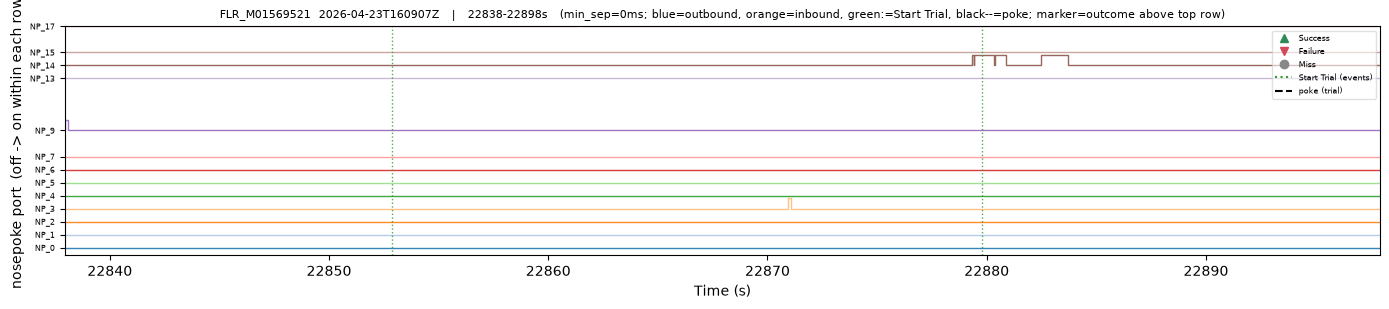

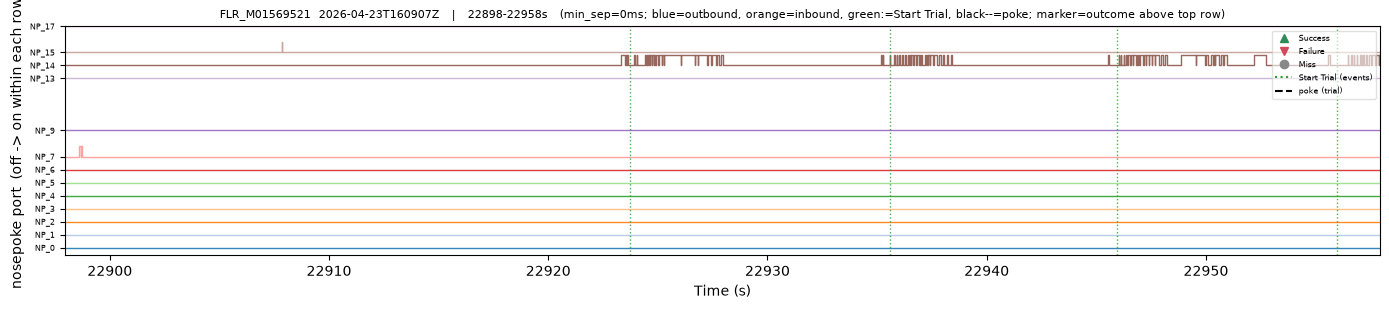

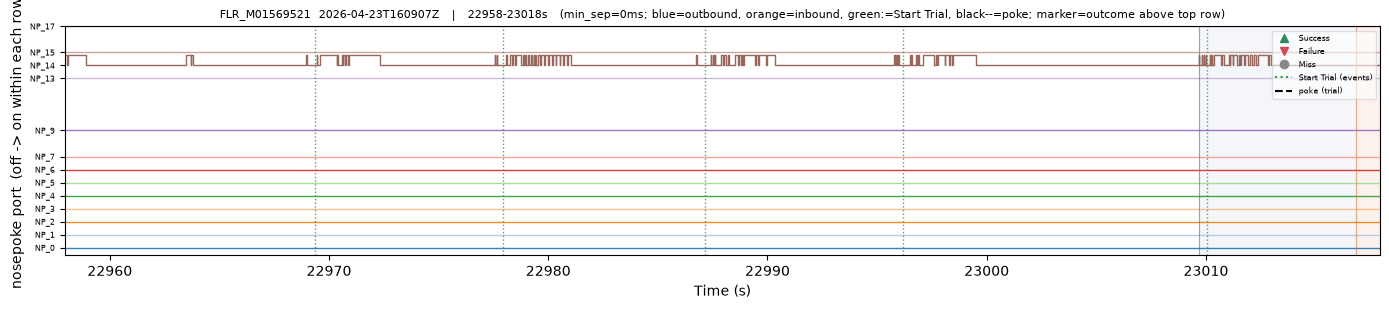

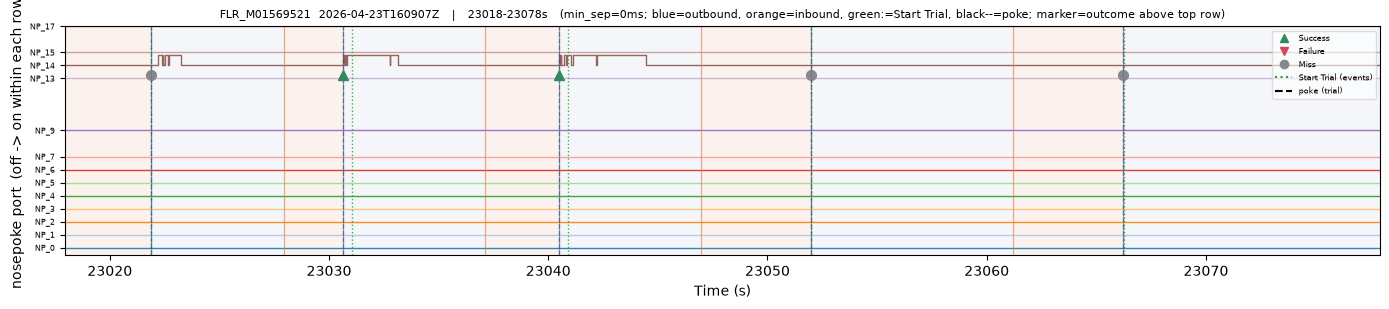

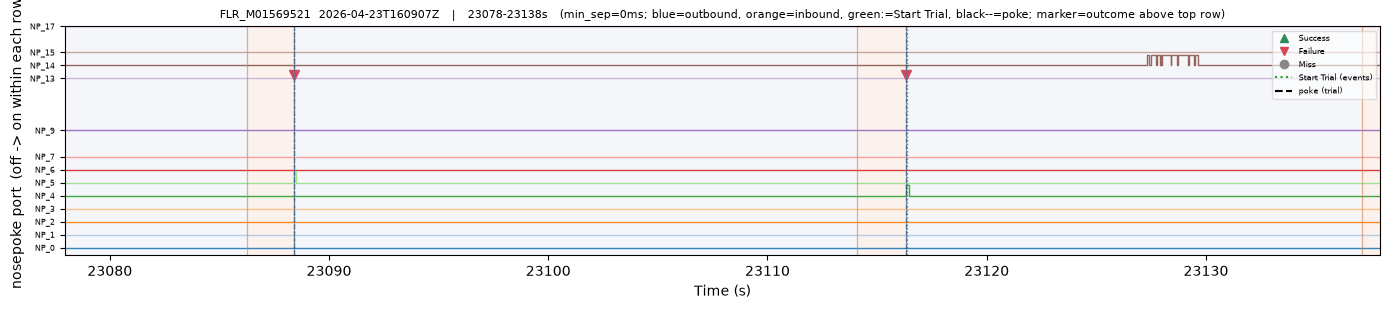

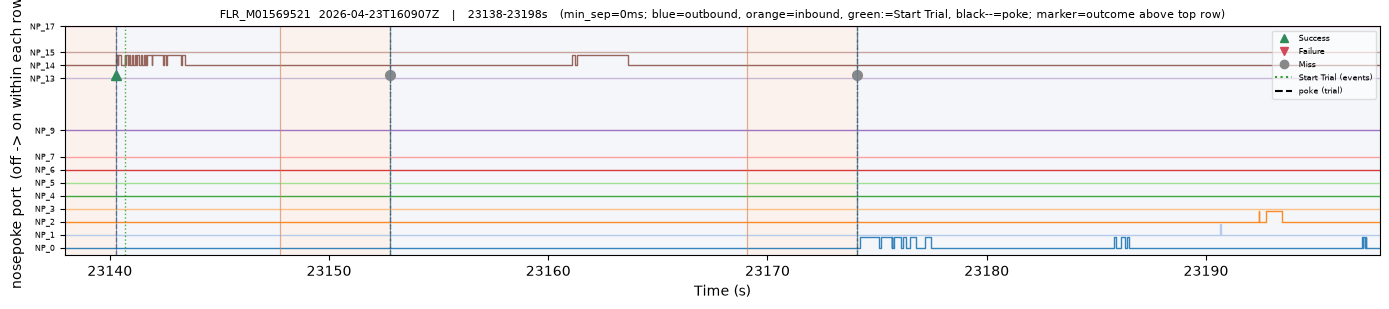

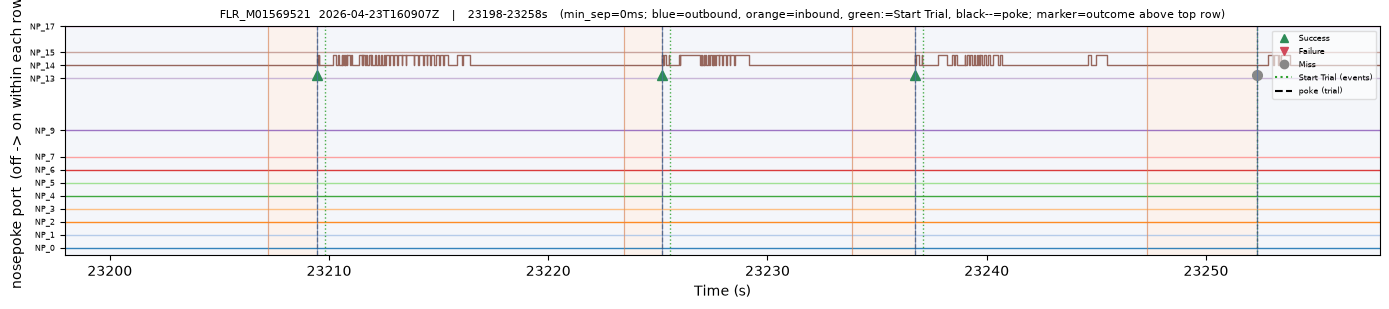

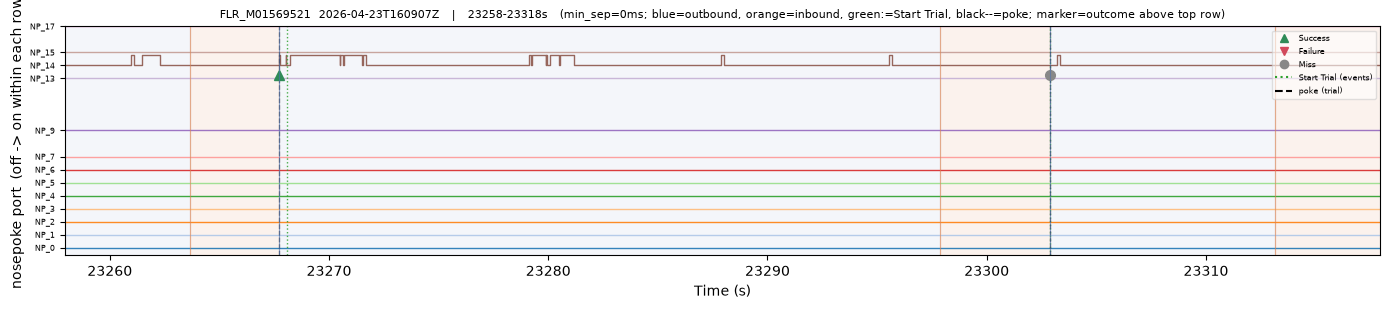

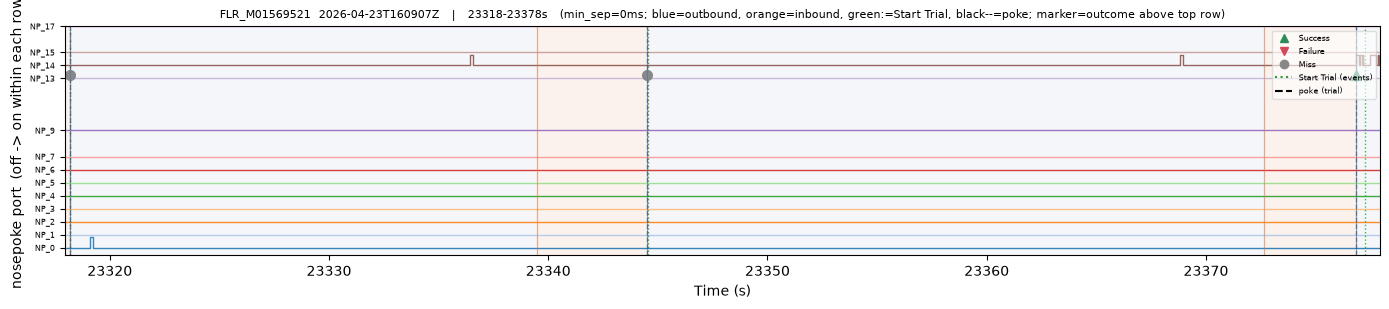

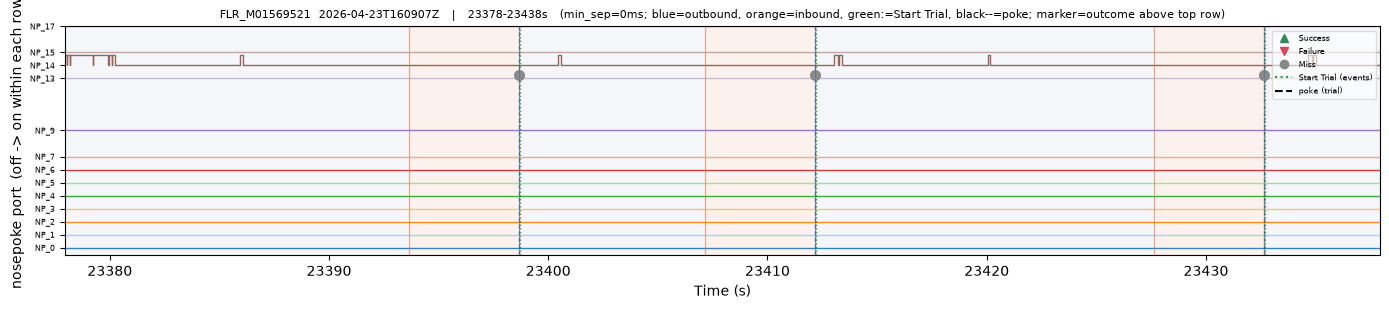

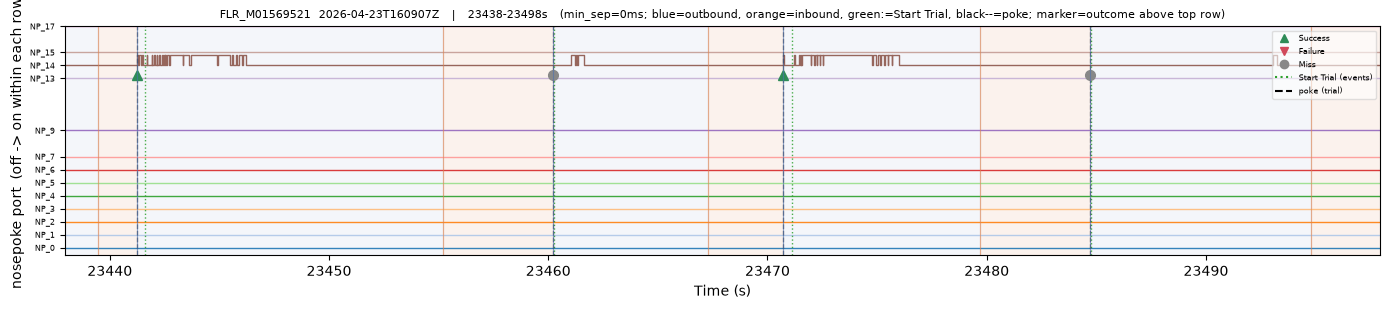

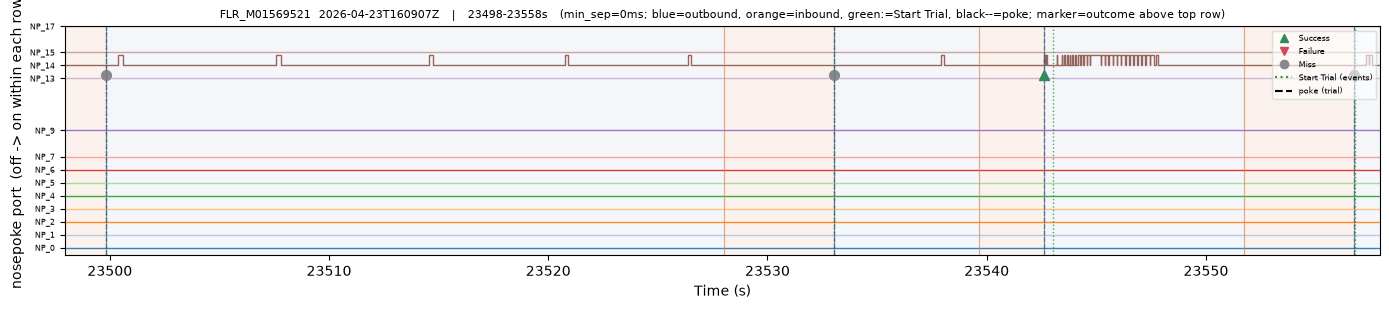

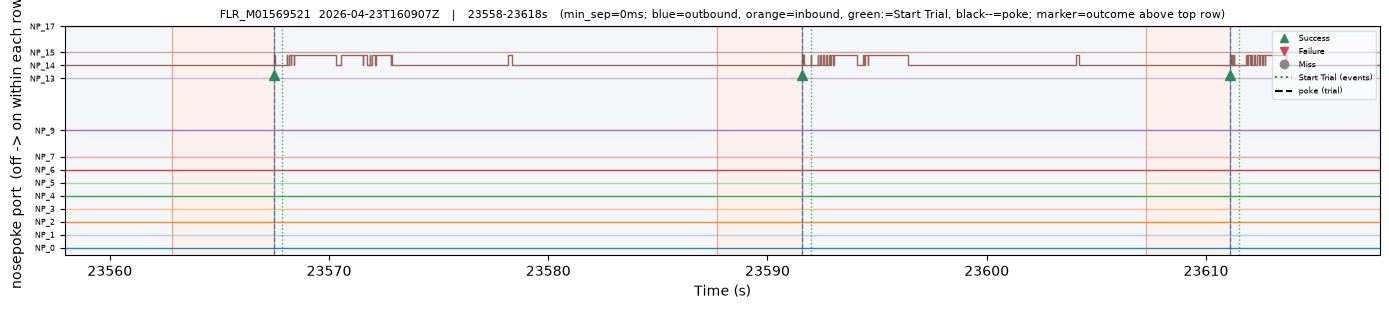

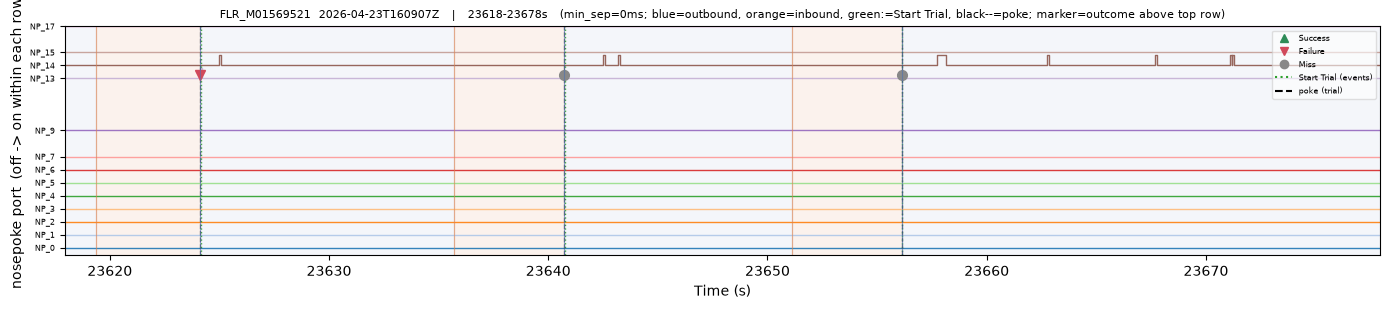

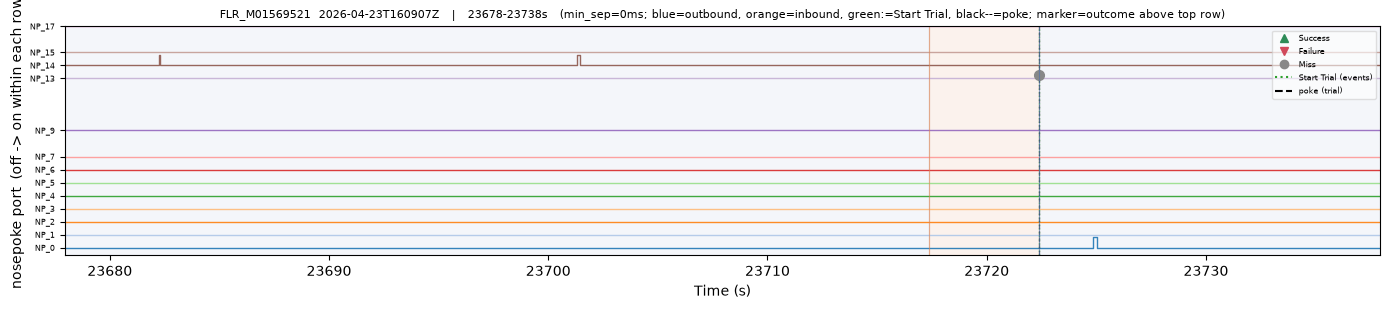

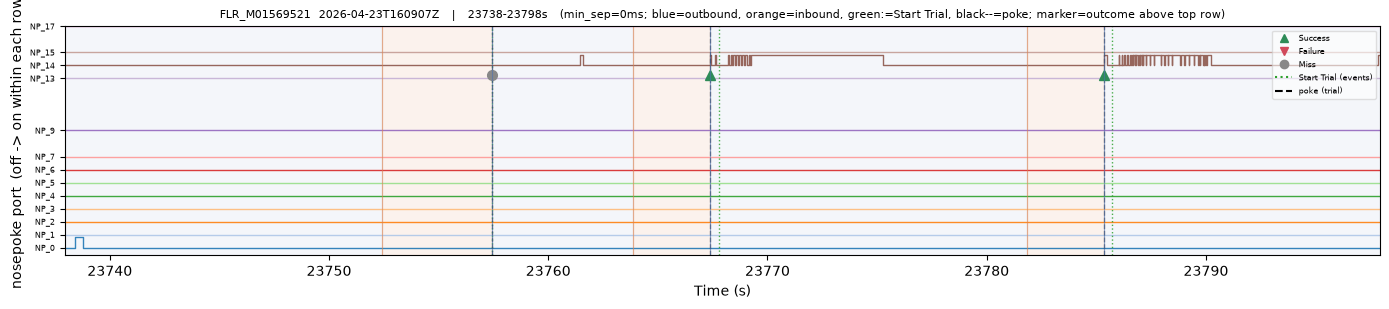

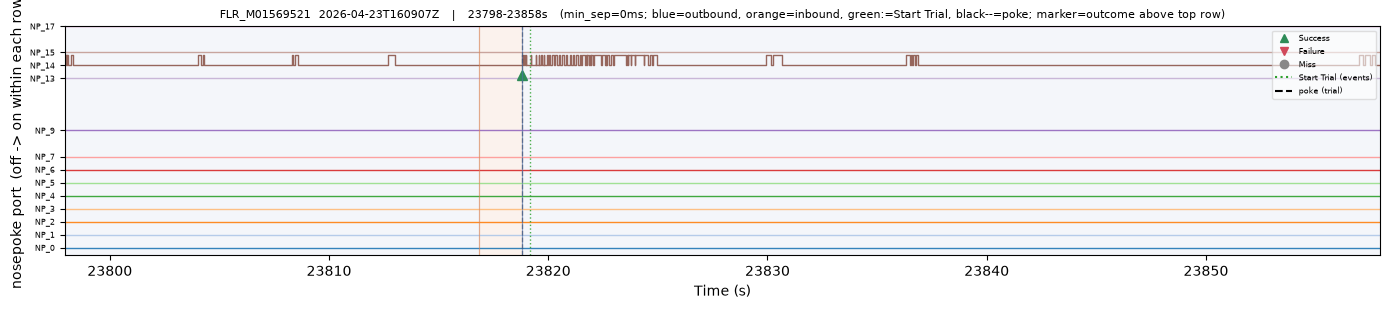

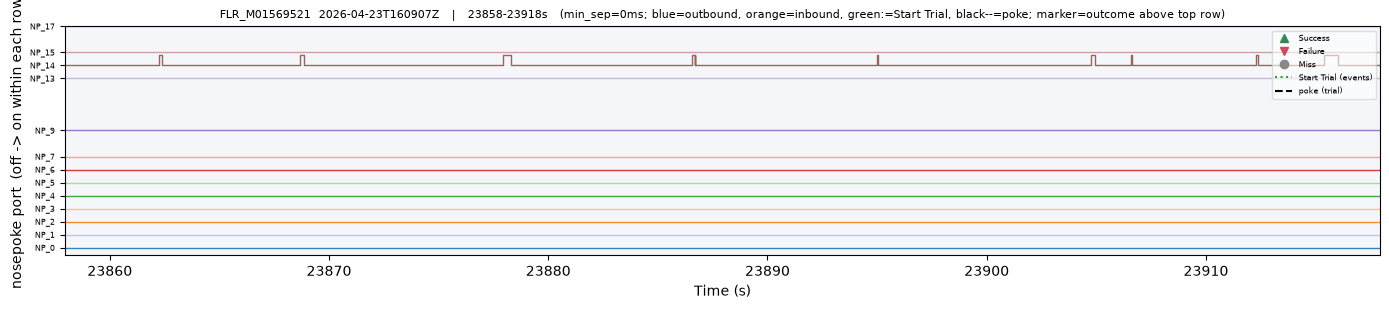

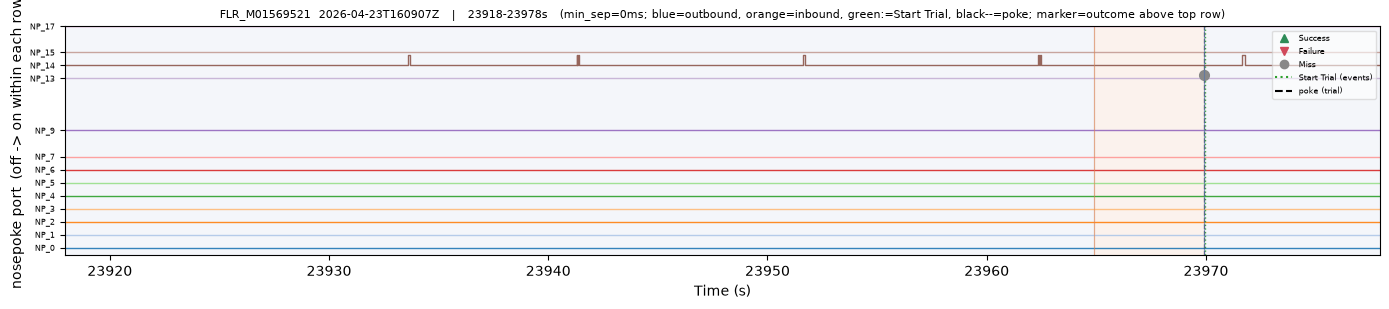

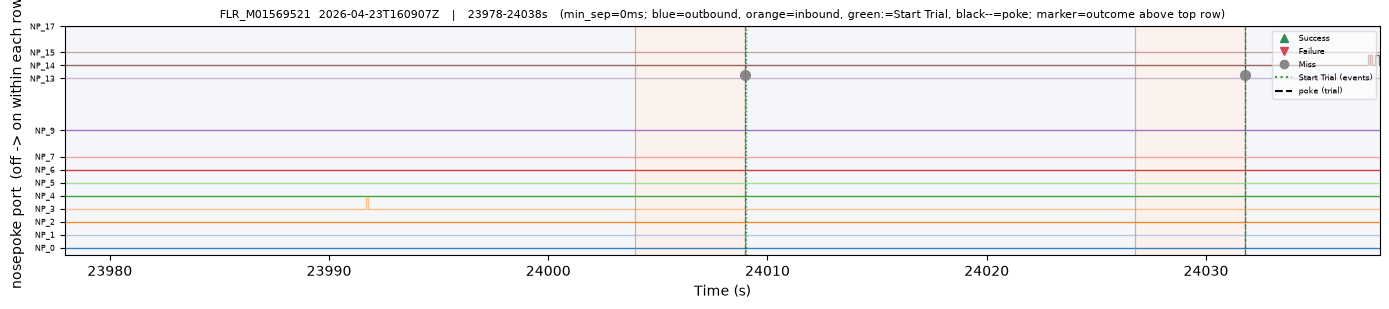

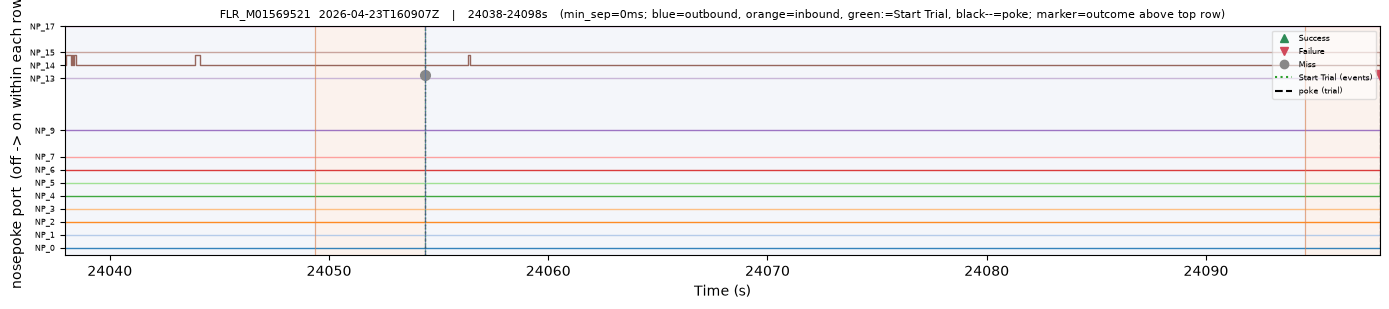

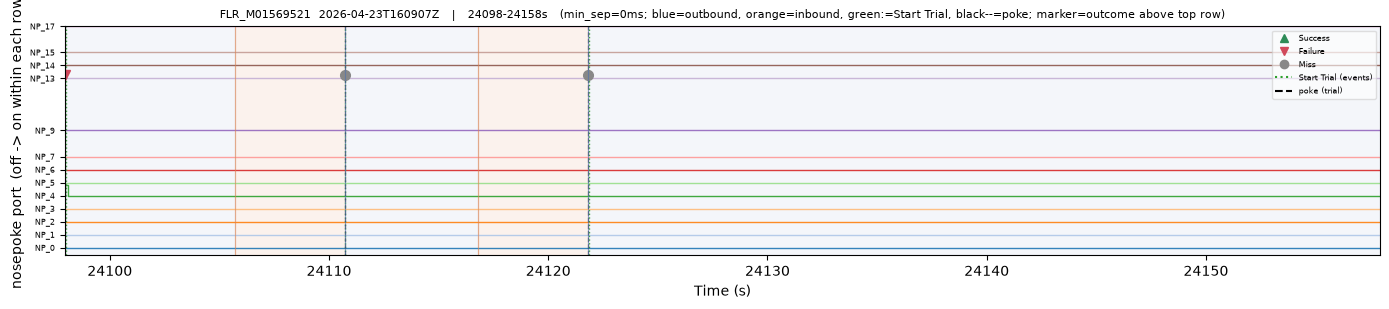

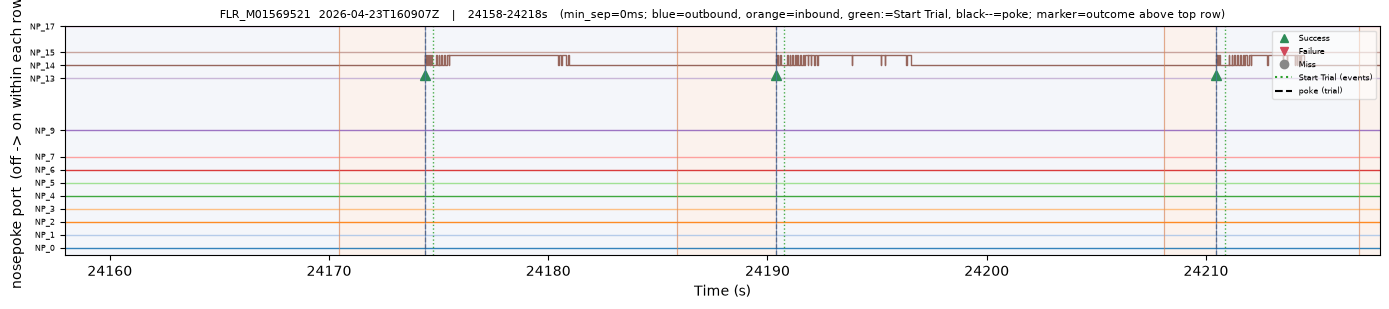

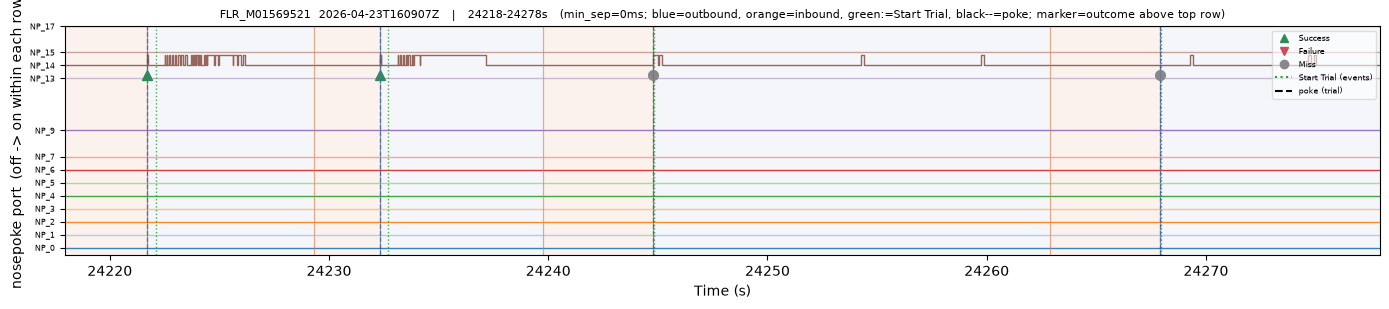

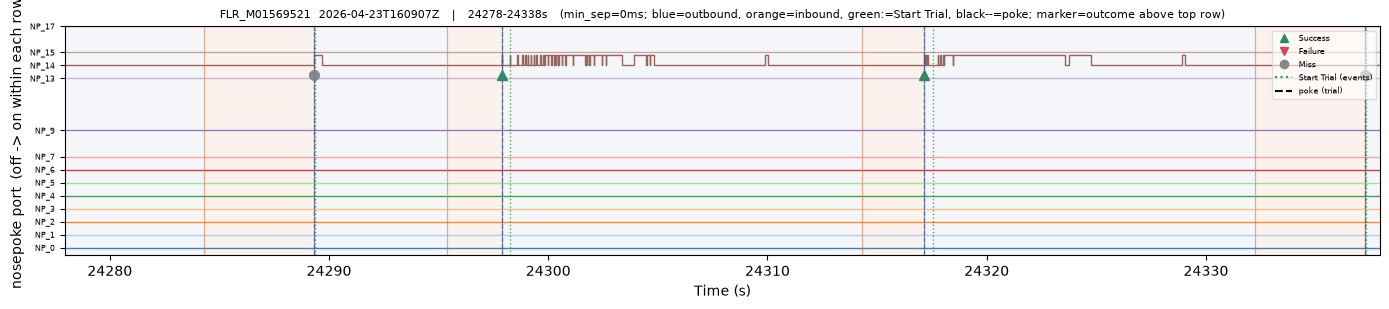

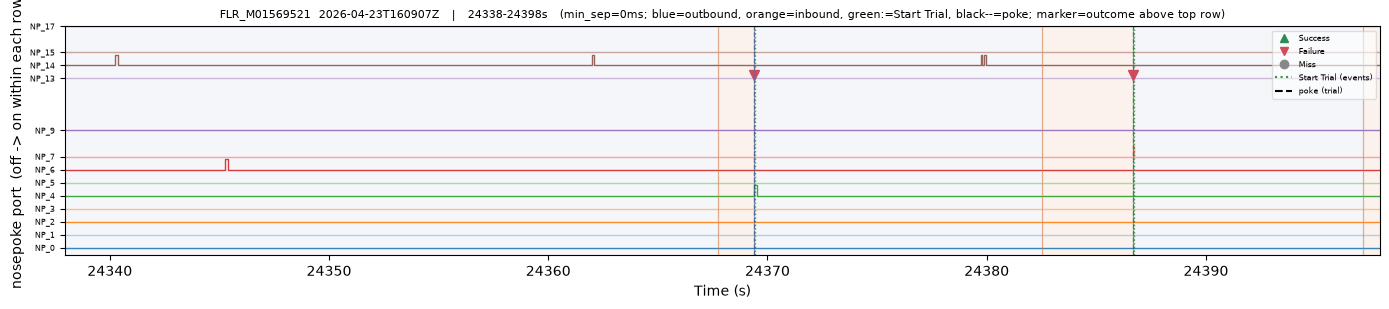

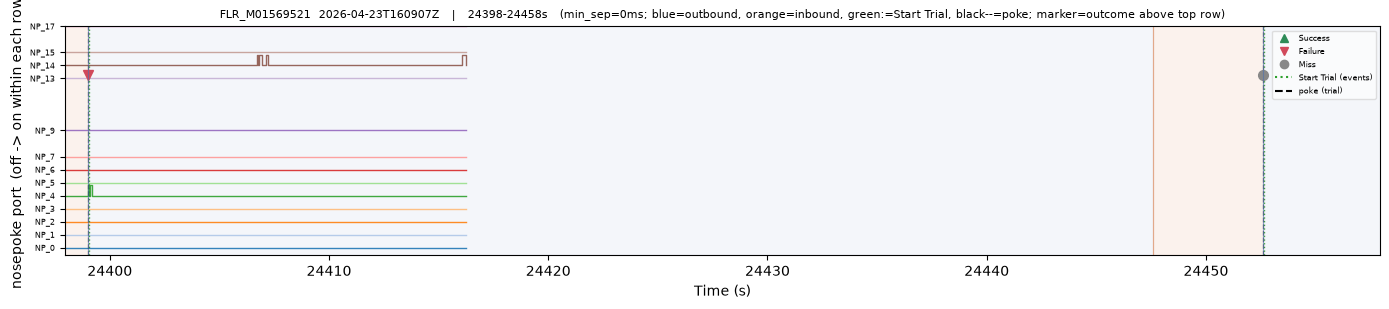

In [26]:
# Per-session activation traces, coloured PER nosepoke port, each on its OWN row (y = port; off -> on within the row),
# split into a new panel every `window_s` seconds. Reads `active_nosepoke` (MIN_SEP already applied), so the
# separation drawn here is the same one baked into every poke count below. Overlaid per trial:
# OUTBOUND leg (blue span), INBOUND leg (orange span), decision poke (black dashed) + outcome marker
# (Success ^, Failure v, Miss o), and raw 'Start Trial' events (green dotted, read from the session
# CSV since the raw events aren't in `result`). Self-contained.
from matplotlib.lines import Line2D

OUTCOME_STYLE = {'Success': ('#2e8b57', '^'), 'Failure': ('#d1495b', 'v'), 'Miss': ('#888888', 'o')}


def _start_trial_times(root, session, prefix='Start Trial'):
    """Seconds of raw '<prefix>' events from a session's ExperimentEvents CSV (same clock as Time).
    Parsed by splitting on the FIRST comma only, since some event strings contain commas."""
    matches = sorted(pathlib.Path(root).glob(f'**/{session}/ExperimentEvents/*.csv'))
    if not matches:
        return np.array([])
    lines = pathlib.Path(matches[0]).read_text().splitlines()[1:]      # drop the header row
    rows = [ln.split(',', 1) for ln in lines if ln]
    ev = pd.DataFrame(rows, columns=['Seconds', 'Value'])
    return ev.loc[ev['Value'].str.startswith(prefix), 'Seconds'].astype(float).to_numpy()


def _bridged_step(g, min_sep, tmin, tmax, *, high=1):
    """(x, y) step points for a port's beam status, bridging OFF gaps shorter than min_sep so short
    releases merge into one ON period. min_sep=0 -> raw. Use with ax.step(where='post')."""
    g = g.dropna(subset=['state']).sort_values('Time')
    tt, st = g['Time'].to_numpy(), g['state'].to_numpy()
    if len(tt) == 0:
        return np.array([tmin, tmax]), np.array([0, 0])
    keep = np.ones(len(st), bool); keep[1:] = st[1:] != st[:-1]        # state transitions only
    tt, st = tt[keep], st[keep]
    intervals = [[tt[i], tt[i + 1] if i + 1 < len(tt) else tmax]       # ON interval [rise, next edge]
                 for i in range(len(st)) if st[i] == high]
    merged = []
    for s, e in intervals:
        if merged and s - merged[-1][1] < min_sep:                    # OFF gap < min_sep -> same poke
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    x, y = [tmin], [0]
    for s, e in merged:
        x += [s, e]; y += [1, 0]
    x.append(tmax); y.append(0)
    return np.array(x), np.array(y)


def plot_session_traces(activations, trials, sessions=None, *, window_s=60, min_sep=0.0, root=ROOT,
                        event_prefix='Start Trial', figsize=(14, 3.2)):
    """Draw the per-session beam traces from the `active_nosepoke` long table. `min_sep` here only
    re-bridges for display (idempotent when the table already carries the same separation) and sets
    the label in the panel title."""
    al = activations[['session', 'port', 'Time', 'state']]
    if sessions is None:
        sessions = list(pd.unique(trials['session']))
    cmap = plt.get_cmap('tab20')
    for sess in sessions:
        sub = al[al['session'] == sess]
        if sub.empty:
            continue
        ports = sorted(sub['port'].unique(), key=lambda p: int(p.split('_')[-1]))
        colours = {p: cmap(i % 20) for i, p in enumerate(ports)}
        tr_sess = trials[trials['session'] == sess]
        st_ev = _start_trial_times(root, sess, event_prefix)
        tmin, tmax = sub['Time'].min(), sub['Time'].max()
        steps = {p: _bridged_step(sub[sub['port'] == p], min_sep, tmin, tmax) for p in ports}
        _m = tr_sess['mouseID'].iloc[0] if len(tr_sess) else ''
        for w0 in np.arange(tmin, tmax, window_s):
            w1 = w0 + window_s
            fig, ax = plt.subplots(figsize=figsize)
            for p in ports:
                k = int(p.split('_')[-1])
                x, y = steps[p]
                ax.step(x, y * 0.8 + k, where='post', lw=1.0, alpha=0.9, color=colours[p], label=p)
            for t in st_ev[(st_ev >= w0) & (st_ev < w1)]:
                ax.axvline(t, color='#2ca02c', ls=':', lw=1.0, alpha=0.85)                # raw Start Trial
            wt = tr_sess[(tr_sess['start_time'] < w1) & (tr_sess['end_time'] >= w0)]
            for _, r in wt.iterrows():
                has_in = pd.notna(r['outbound_end_time'])
                ob_end = r['outbound_end_time'] if has_in else r['end_time']
                ax.axvspan(r['start_time'], ob_end, color='#4c72b0', alpha=0.06)           # outbound leg
                ax.axvline(r['start_time'], color='#4c72b0', lw=0.8, alpha=0.6)            # outbound start
                if has_in:
                    ax.axvspan(r['outbound_end_time'], r['end_time'], color='#dd8452', alpha=0.10)  # inbound leg
                    ax.axvline(r['outbound_end_time'], color='#dd8452', lw=0.8, alpha=0.6)          # inbound start (tz)
                col, mk = OUTCOME_STYLE.get(r['outcome'], ('k', 'x'))
                ax.axvline(r['end_time'], color='k', ls='--', lw=0.9, alpha=0.55)          # decision poke
                ax.plot(r['end_time'], len(ports) + 0.3, marker=mk, color=col, ms=7)                    # outcome marker
            ax.set_xlim(w0, w1); ax.set_ylim(-0.6, len(ports) + 0.8)
            ax.set_yticks([int(p.split('_')[-1]) for p in ports]); ax.set_yticklabels(ports, fontsize=6)
            ax.set_xlabel('Time (s)'); ax.set_ylabel('nosepoke port  (off -> on within each row)')
            ax.set_title(f'{_m}  {sess}   |   {w0:.0f}-{w1:.0f}s   (min_sep={min_sep * 1000:.0f}ms; '
                         f'blue=outbound, orange=inbound, green:=Start Trial, black--=poke; marker=outcome above top row)', fontsize=8)
            _extra = [Line2D([0], [0], marker=mk, ls='', color=c, label=o) for o, (c, mk) in OUTCOME_STYLE.items()]
            _extra.append(Line2D([0], [0], color='#2ca02c', ls=':', label='Start Trial (events)'))
            _extra.append(Line2D([0], [0], color='k', ls='--', label='poke (trial)'))
            ax.legend(handles=_extra, loc='upper right', fontsize=6, framealpha=0.6)
            fig.tight_layout(); plt.show()


# One session, 60s panels. active_nosepoke already carries MIN_SEP; pass it here for the title label.
_s0 = pd.unique(trials_filtered['session'])[0]
plot_session_traces(active_nosepoke, trials_filtered, sessions=[_s0], window_s=60, min_sep=MIN_SEP)

In [27]:
# Distance (in ROWS of the `active_nosepoke` table = Time steps, NOT seconds) between
# each ACTIVE (1) sample of a port and the NEXT active sample of that SAME port: for every poke
# sample, how many table rows until that port reads 1 again? Computed within (session, port) so it
# never crosses a session boundary. dist_rows == 1 => the port is active in back-to-back table rows.
_al = active_nosepoke.copy()
_al['row'] = _al.groupby('session')['Time'].rank(method='dense').astype(int)   # row # within the session's table
_act = _al[_al['state'] == 1].sort_values(['session', 'port', 'Time']).copy()
_act['dist_rows'] = _act.groupby(['session', 'port'])['row'].shift(-1) - _act['row']
active_gap_rows = _act.dropna(subset=['dist_rows']).astype({'dist_rows': int})

display(active_gap_rows[['session', 'port', 'Time', 'row', 'dist_rows']])
print('rows to next active at the same port -- distribution (top 20):')
print(active_gap_rows['dist_rows'].value_counts().sort_index().head(20).to_string())

,session,port,Time,row,dist_rows
348,2026-04-21T144313Z,NP_0,18274.919328,349,66
244,2026-04-21T144313Z,NP_12,18203.280128,245,2
246,2026-04-21T144313Z,NP_12,18204.258400,247,2
248,2026-04-21T144313Z,NP_12,18204.553216,249,2
254,2026-04-21T144313Z,NP_13,18213.310336,255,2
...,...,...,...,...,...
31246,2026-06-21T093349Z,NP_0,7133.783872,1427,2
31248,2026-06-21T093349Z,NP_0,7133.873120,1429,2
31250,2026-06-21T093349Z,NP_0,7148.445408,1431,2
31252,2026-06-21T093349Z,NP_0,7157.318944,1433,2


rows to next active at the same port -- distribution (top 20):
dist_rows
2     15013
4       116
6        35
8        21
10        9
12        9
14        7
16        8
18        1
20        3
22        3
24        7
26        3
28        2
30        1
32        5
34        4
38        3
40        3
42        4


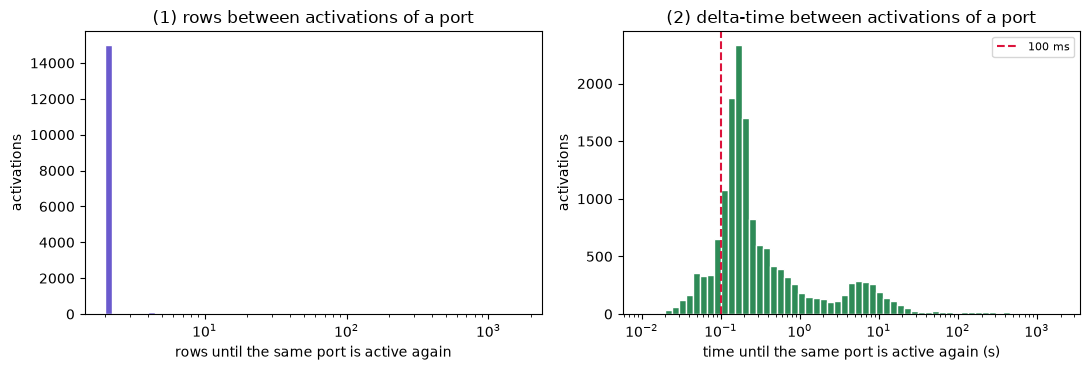

15394 port-activation gaps.  rows: median 2, min 2, max 1702;  time: median 193 ms, 13.4% < 100 ms


In [28]:
# For each PORT, the gap until that SAME port is active (1) again - two distributions:
#   (1) number of ROWS (Time-steps of the active_nosepoke table) between consecutive activations of the port
#   (2) delta-TIME (s) between consecutive activations of the port
# i.e. if port p is active, how many rows / how much time until port p is active again. Computed
# within (session, port); the last activation of each port (no 'next') drops out.
_al = active_nosepoke[['session', 'Time', 'port', 'state']].copy()
_al = _al.sort_values(['session', 'Time']).reset_index(drop=True)
_al['row'] = _al.groupby('session')['Time'].rank(method='dense').astype(int)   # row # within the session's table
_act = _al[_al['state'] == 1].sort_values(['session', 'port', 'Time']).copy()
_grp = _act.groupby(['session', 'port'])
_act['gap_rows'] = _grp['row'].shift(-1) - _act['row']
_act['gap_time'] = _grp['Time'].shift(-1) - _act['Time']
gaps = _act.dropna(subset=['gap_rows', 'gap_time'])
_gr = gaps['gap_rows'][gaps['gap_rows'] > 0]
_gt = gaps['gap_time'][gaps['gap_time'] > 0]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
_rb = np.logspace(np.log10(_gr.min()), np.log10(_gr.max()), 60)
ax[0].hist(_gr, bins=_rb, color='#6a5acd', edgecolor='white'); ax[0].set_xscale('log')
ax[0].set_xlabel('rows until the same port is active again'); ax[0].set_ylabel('activations')
ax[0].set_title('(1) rows between activations of a port')
# to zoom, use a POSITIVE lower bound on the log axis, e.g.: ax[0].set_xlim(_gr.min(), _gr.quantile(0.99))
_tb = np.logspace(np.log10(_gt.min()), np.log10(_gt.max()), 60)
ax[1].hist(_gt, bins=_tb, color='#2e8b57', edgecolor='white'); ax[1].set_xscale('log')
ax[1].axvline(0.1, color='crimson', ls='--', label='100 ms'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('time until the same port is active again (s)'); ax[1].set_ylabel('activations')
ax[1].set_title('(2) delta-time between activations of a port')
fig.tight_layout(); plt.show()

print(f'{len(gaps)} port-activation gaps.  rows: median {int(_gr.median())}, min {int(_gr.min())}, '
      f'max {int(_gr.max())};  time: median {_gt.median() * 1000:.0f} ms, {(_gt < 0.1).mean():.1%} < 100 ms')

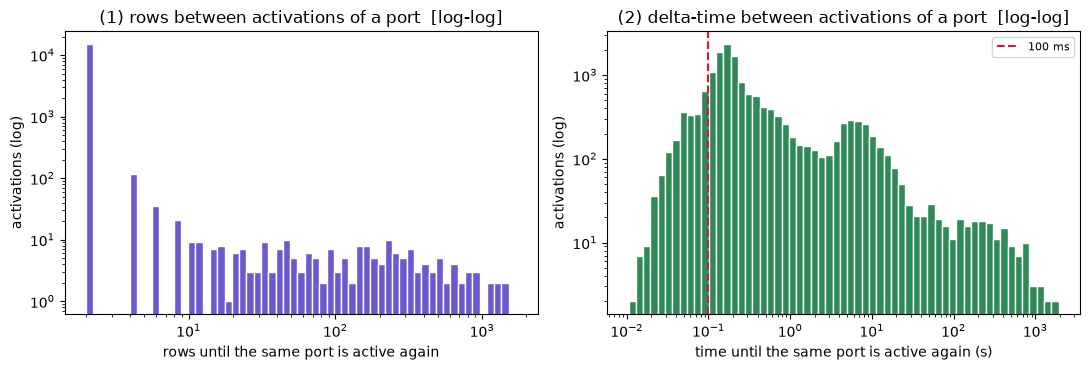

In [29]:
# LOG-LOG copy of the two per-port gap distributions above (both x and y on a log scale, since the
# counts span a huge range). (1) rows and (2) delta-time until the SAME port is active (1) again.
_al = active_nosepoke[['session', 'Time', 'port', 'state']].copy()
_al = _al.sort_values(['session', 'Time']).reset_index(drop=True)
_al['row'] = _al.groupby('session')['Time'].rank(method='dense').astype(int)   # row # within the session's table
_act = _al[_al['state'] == 1].sort_values(['session', 'port', 'Time']).copy()
_grp = _act.groupby(['session', 'port'])
_act['gap_rows'] = _grp['row'].shift(-1) - _act['row']
_act['gap_time'] = _grp['Time'].shift(-1) - _act['Time']
gaps = _act.dropna(subset=['gap_rows', 'gap_time'])
_gr = gaps['gap_rows'][gaps['gap_rows'] > 0]
_gt = gaps['gap_time'][gaps['gap_time'] > 0]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
_rb = np.logspace(np.log10(_gr.min()), np.log10(_gr.max()), 60)
ax[0].hist(_gr, bins=_rb, color='#6a5acd', edgecolor='white')
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].set_xlabel('rows until the same port is active again'); ax[0].set_ylabel('activations (log)')
ax[0].set_title('(1) rows between activations of a port  [log-log]')
_tb = np.logspace(np.log10(_gt.min()), np.log10(_gt.max()), 60)
ax[1].hist(_gt, bins=_tb, color='#2e8b57', edgecolor='white')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].axvline(0.1, color='crimson', ls='--', label='100 ms'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('time until the same port is active again (s)'); ax[1].set_ylabel('activations (log)')
ax[1].set_title('(2) delta-time between activations of a port  [log-log]')
fig.tight_layout(); plt.show()

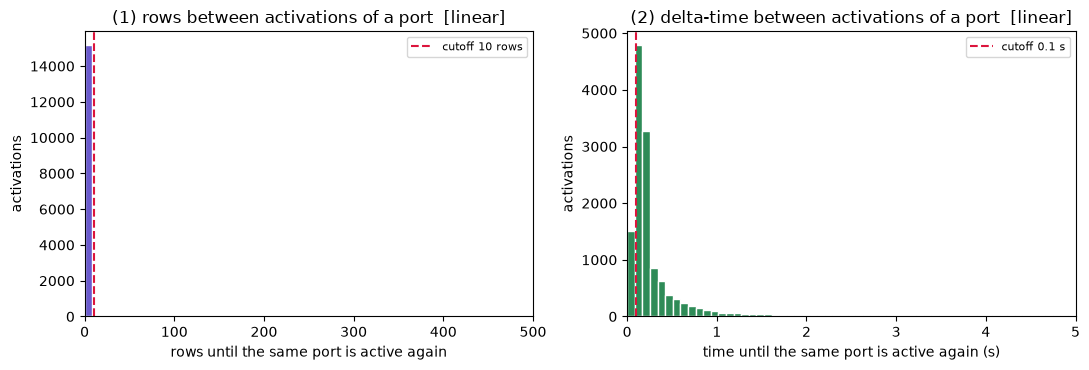

TIME  cutoff 0.1s : 13.4% below (same poke), 86.6% at/above (actual gaps)
ROWS  cutoff 10 : 98.6% below, 1.4% at/above


In [30]:
# LINEAR version of the two per-port gap distributions, with an adjustable CUTOFF that splits a
# short re-trigger (probably the SAME poke) from an 'actual gap' (a genuinely separate visit).
# e.g. gaps >= 1 s are probably real gaps. Tune the toggles; the view zooms around the cutoff so the
# linear axis stays readable (the full distribution has a long thin tail). The below/above %% are
# computed on ALL gaps, not just the zoomed view.
cutoff_s = 0.1                    # TIME cutoff (s): gaps below ~ same poke; at/above ~ actual gap
cutoff_rows = 10  # ROWS cutoff (table rows): same idea in row units
view_max_s = 50 * cutoff_s         # x-range of the time panel (zoom around the cutoff)
view_max_rows = 50 * cutoff_rows   # x-range of the rows panel

_al = active_nosepoke[['session', 'Time', 'port', 'state']].copy()
_al = _al.sort_values(['session', 'Time']).reset_index(drop=True)
_al['row'] = _al.groupby('session')['Time'].rank(method='dense').astype(int)   # row # within the session's table
_act = _al[_al['state'] == 1].sort_values(['session', 'port', 'Time']).copy()
_grp = _act.groupby(['session', 'port'])
_act['gap_rows'] = _grp['row'].shift(-1) - _act['row']
_act['gap_time'] = _grp['Time'].shift(-1) - _act['Time']
gaps = _act.dropna(subset=['gap_rows', 'gap_time'])
_gr = gaps['gap_rows'][gaps['gap_rows'] > 0]
_gt = gaps['gap_time'][gaps['gap_time'] > 0]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(_gr, bins=np.linspace(0, view_max_rows, 60), color='#6a5acd', edgecolor='white')
ax[0].axvline(cutoff_rows, color='crimson', ls='--', label=f'cutoff {cutoff_rows} rows')
ax[0].set_xlim(0, view_max_rows); ax[0].legend(fontsize=8)
ax[0].set_xlabel('rows until the same port is active again'); ax[0].set_ylabel('activations')
ax[0].set_title('(1) rows between activations of a port  [linear]')
ax[1].hist(_gt, bins=np.linspace(0, view_max_s, 60), color='#2e8b57', edgecolor='white')
ax[1].axvline(cutoff_s, color='crimson', ls='--', label=f'cutoff {cutoff_s:g} s')
ax[1].set_xlim(0, view_max_s); ax[1].legend(fontsize=8)
ax[1].set_xlabel('time until the same port is active again (s)'); ax[1].set_ylabel('activations')
ax[1].set_title('(2) delta-time between activations of a port  [linear]')
fig.tight_layout(); plt.show()

print(f'TIME  cutoff {cutoff_s:g}s : {(_gt < cutoff_s).mean():.1%} below (same poke), '
      f'{(_gt >= cutoff_s).mean():.1%} at/above (actual gaps)')
print(f'ROWS  cutoff {cutoff_rows} : {(_gr < cutoff_rows).mean():.1%} below, '
      f'{(_gr >= cutoff_rows).mean():.1%} at/above')

In [31]:
# Poke-onset extraction and per-trial outbound / inbound classification. Onsets are just the rising
# edges of `active_nosepoke` - MIN_SEP is already baked into that table, so there is no bridging here.
def poke_onsets(activations_long_df, *, high=1, refractory=0.0, session_col='session',
                port_col='port', time_col='Time', state_col='state'):
    """One row per poke ONSET (beam-state rising to HIGH) in `active_nosepoke`. Adds integer
    `port_index`. Since MIN_SEP separation is already applied upstream, this is simply the rising edges.

    refractory (seconds): if >0, additionally drop any onset within `refractory` of the previous onset
    at the SAME port (an extra debounce on top of MIN_SEP). Default 0.0 keeps every edge."""
    a = activations_long_df.sort_values([session_col, port_col, time_col]).copy()
    a['_prev'] = a.groupby([session_col, port_col])[state_col].shift()
    out = a.loc[(a[state_col] == high) & (a['_prev'] != high),
                [session_col, port_col, time_col]].reset_index(drop=True)
    out['port_index'] = out[port_col].str.split('_').str[-1].astype(int)   # 'NP_5' -> 5
    if refractory and refractory > 0:
        out = out.sort_values([session_col, port_col, time_col])
        gap = out.groupby([session_col, port_col])[time_col].diff()   # gap to previous same-port onset
        out = out[gap.isna() | (gap >= refractory)].reset_index(drop=True)
    return out


def pokes_by_trial(onsets, trials, *, session_col='session', time_col='Time'):
    """Assign each onset to its trial and tag leg (outbound/inbound) + is_target.
    Miss trials (tz_triggered_time is NaN) have no inbound leg -> all counted outbound."""
    tw = (trials[[session_col, 'trial_index', 'start_time', 'end_time',
                  'outbound_end_time', 'CorrectPort']]
          .sort_values('start_time').reset_index(drop=True))
    o = onsets.sort_values(time_col).reset_index(drop=True)
    tagged = pd.merge_asof(o, tw, left_on=time_col, right_on='start_time',
                           by=session_col, direction='backward')
    tagged = tagged[(tagged[time_col] <= tagged['end_time']).fillna(False)].copy()
    cutoff = tagged['outbound_end_time'].fillna(tagged['end_time'])
    tagged['leg'] = np.where(tagged[time_col] <= cutoff, 'outbound', 'inbound')
    tagged['is_target'] = tagged['port_index'] == tagged['CorrectPort']
    return tagged


def per_trial_poke_counts(tagged, trials, *, session_col='session'):
    """Add n_<leg>_all / n_<leg>_target columns per trial (0 where a trial had no pokes)."""
    g = (tagged.groupby([session_col, 'trial_index', 'leg'])
         .agg(all_=('port_index', 'size'), target=('is_target', 'sum')).reset_index())
    wide = g.pivot_table(index=[session_col, 'trial_index'], columns='leg',
                         values=['all_', 'target'], fill_value=0)
    wide.columns = [f'n_{leg}_{"all" if k == "all_" else "target"}' for k, leg in wide.columns]
    wide = wide.reset_index()
    out = trials.merge(wide, on=[session_col, 'trial_index'], how='left')
    for c in [c for c in wide.columns if c.startswith('n_')]:
        out[c] = out[c].fillna(0).astype(int)
    return out


# Onsets = rising edges of active_nosepoke (MIN_SEP already applied). Bump refractory (e.g. 0.1) only
# if the onset-gap diagnostic in the next cell still shows sub-threshold re-triggers to collapse.
onsets = poke_onsets(active_nosepoke)
tagged = pokes_by_trial(onsets, trials_filtered)
poke_trials = per_trial_poke_counts(tagged, trials_filtered)
poke_trials[['mouseID', 'training_day', 'trial_index', 'outcome', 'TTT',
             'n_outbound_all', 'n_outbound_target', 'n_inbound_all']].head()

,mouseID,training_day,trial_index,outcome,TTT,n_outbound_all,n_outbound_target,n_inbound_all
0,FLR_M01569521,1,11,Miss,7.179488,18,18,0
1,FLR_M01569521,1,12,Success,6.083008,4,4,1
2,FLR_M01569521,1,13,Success,6.446976,3,3,1
3,FLR_M01569521,1,14,Miss,6.457504,5,5,0
4,FLR_M01569521,1,15,Miss,9.236992,0,0,0


In [32]:
# Onset-gap diagnostic | how close together are successive rising edges at the SAME port?
# Activations (HARP reg 32) is logged on-change at sub-ms precision, so each poke is a rising edge;
# a single bouncy/held contact can log as several rapid rising edges. This measures the gap (s)
# between successive same-port onsets so you can pick a debounce threshold: a spike of gaps under
# ~0.1 s means those are almost certainly ONE physical poke double-counted -> set poke_onsets(...,
# refractory=<threshold>) above and re-run. If gaps are all comfortably large, no debounce needed.
_gap = (onsets.sort_values(['session', 'port', 'Time'])
        .groupby(['session', 'port'])['Time'].diff().dropna())
print(f'{len(_gap)} successive same-port onset gaps (seconds). Distribution:')
print(_gap.describe(percentiles=[.01, .05, .1, .25, .5, .9]).to_string())
print('\nshare of onsets that closely FOLLOW the previous same-port onset (candidate double-counts):')
for _thr in (0.02, 0.05, 0.1, 0.2, 0.5):
    print(f'  gap < {_thr * 1000:4.0f} ms : {(_gap < _thr).mean():6.1%}   '
          f'({int((_gap < _thr).sum())} of {len(_gap)} onsets)')

15394 successive same-port onset gaps (seconds). Distribution:
count    15394.000000
mean         5.384750
std         47.812610
min          0.010528
1%           0.031381
5%           0.054560
10%          0.085715
25%          0.135040
50%          0.192608
90%          5.577395
max       1923.508064

share of onsets that closely FOLLOW the previous same-port onset (candidate double-counts):
  gap <   20 ms :   0.1%   (19 of 15394 onsets)
  gap <   50 ms :   3.8%   (586 of 15394 onsets)
  gap <  100 ms :  13.4%   (2059 of 15394 onsets)
  gap <  200 ms :  52.4%   (8070 of 15394 onsets)
  gap <  500 ms :  74.1%   (11410 of 15394 onsets)


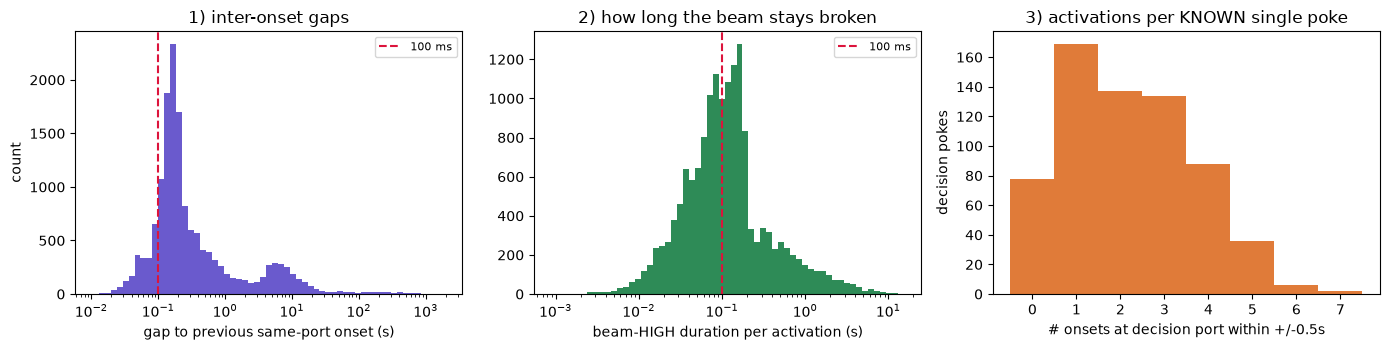

1) inter-onset gap: median 193 ms; 13.4% < 100 ms, 0.1% < 20 ms
2) beam-HIGH per activation: median 106 ms; 22.8% < 50 ms
3) onsets within +/-0.5s of a KNOWN decision poke: mean 2.20; 62.0% have >1 (chatter), 12.0% have 0 (coverage gap)


In [33]:
# Investigate | is ONE physical poke logged as several Activations onsets (chatter), or is "many
# activations per poke event" just the exploratory pokes the events log never records? Three views:
#   1) gap to the previous same-port onset        - a spike < ~100 ms = re-triggers of one contact
#   2) how long the beam stays HIGH per activation - very short HIGHs = noise/chatter, not real pokes
#   3) # onsets at the decision port within +/- win of a KNOWN single decision poke (events end_time)
#      - mostly 1 => NO chatter (the multiplicity is exploratory pokes); often > 1 => real chatter.
def beam_intervals(a, *, high=1, session_col='session', port_col='port', time_col='Time', state_col='state'):
    """Per rising edge, the time until the next state change at that port = how long the beam stayed HIGH."""
    a = a.dropna(subset=[state_col]).sort_values([session_col, port_col, time_col]).copy()
    grp = a.groupby([session_col, port_col])
    a['prev_state'] = grp[state_col].shift(1)
    a['next_t'] = grp[time_col].shift(-1)
    ris = a[(a[state_col] == high) & (a['prev_state'] != high)].copy()
    ris['high_dur'] = ris['next_t'] - ris[time_col]
    return ris.dropna(subset=['high_dur'])


_gaps = (onsets.sort_values(['session', 'port', 'Time'])
         .groupby(['session', 'port'])['Time'].diff().dropna())
_gaps = _gaps[_gaps > 0]
_hi = beam_intervals(active_nosepoke)['high_dur']
_hi = _hi[_hi > 0]

# onsets at ChosenPort within +/- win of each Success decision poke (searchsorted per (session, port)).
win = 0.5
_ot = {k: np.sort(g['Time'].to_numpy()) for k, g in onsets.groupby(['session', 'port_index'])}
def _n_near(sess, port, t):
    arr = _ot.get((sess, int(port)))
    if arr is None:
        return 0
    lo, hi = np.searchsorted(arr, [t - win, t + win])
    return int(hi - lo)
poke_onset_counts = (trials_filtered[trials_filtered['outcome'] == 'Success']
                     [['mouseID', 'session', 'trial_index', 'end_time', 'ChosenPort']]
                     .dropna(subset=['end_time']).copy())
poke_onset_counts['n_near'] = [_n_near(s, p, t) for s, p, t in zip(
    poke_onset_counts['session'], poke_onset_counts['ChosenPort'], poke_onset_counts['end_time'])]

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
_gb = np.logspace(np.log10(_gaps.min()), np.log10(_gaps.max()), 60)
ax[0].hist(_gaps, bins=_gb, color='#6a5acd'); ax[0].set_xscale('log')
ax[0].axvline(0.1, color='crimson', ls='--', label='100 ms'); ax[0].legend(fontsize=8)
ax[0].set_xlabel('gap to previous same-port onset (s)'); ax[0].set_ylabel('count')
ax[0].set_title('1) inter-onset gaps')
_hb = np.logspace(np.log10(_hi.min()), np.log10(_hi.max()), 60)
ax[1].hist(_hi, bins=_hb, color='#2e8b57'); ax[1].set_xscale('log')
ax[1].axvline(0.1, color='crimson', ls='--', label='100 ms'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('beam-HIGH duration per activation (s)'); ax[1].set_title('2) how long the beam stays broken')
_nb = np.arange(-0.5, poke_onset_counts['n_near'].max() + 1.5, 1)
ax[2].hist(poke_onset_counts['n_near'], bins=_nb, color='#e07b39')
ax[2].set_xlabel(f'# onsets at decision port within +/-{win}s'); ax[2].set_ylabel('decision pokes')
ax[2].set_title('3) activations per KNOWN single poke')
fig.tight_layout(); plt.show()

print(f'1) inter-onset gap: median {_gaps.median() * 1000:.0f} ms; '
      f'{(_gaps < 0.1).mean():.1%} < 100 ms, {(_gaps < 0.02).mean():.1%} < 20 ms')
print(f'2) beam-HIGH per activation: median {_hi.median() * 1000:.0f} ms; {(_hi < 0.05).mean():.1%} < 50 ms')
print(f'3) onsets within +/-{win}s of a KNOWN decision poke: mean {poke_onset_counts["n_near"].mean():.2f}; '
      f'{(poke_onset_counts["n_near"] > 1).mean():.1%} have >1 (chatter), '
      f'{(poke_onset_counts["n_near"] == 0).mean():.1%} have 0 (coverage gap)')

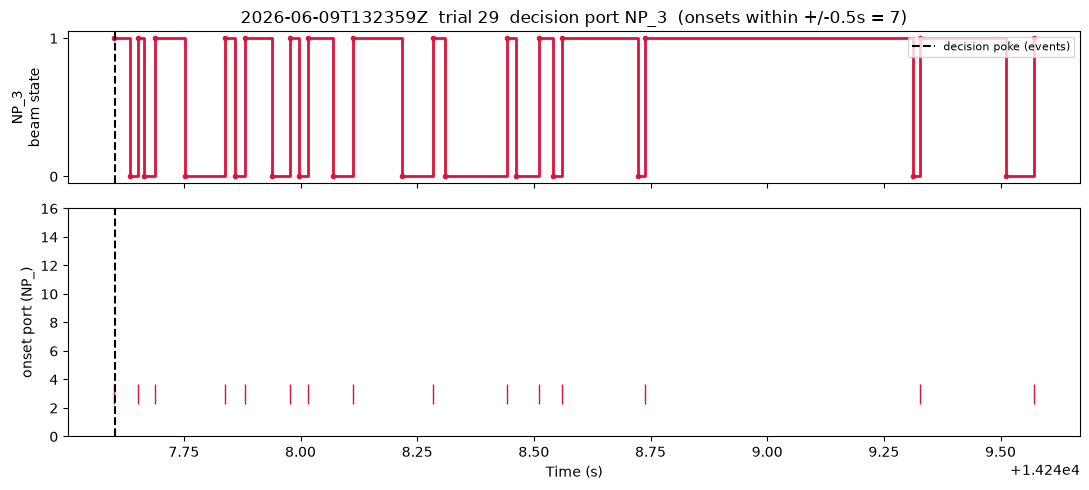

In [34]:
# Zoom | beam state at the decision port around ONE Success decision poke - literally see whether
# a poke is a single clean pulse or several rapid on/off flips (chatter). Top: the NP_<ChosenPort>
# state (step, from active_nosepoke). Bottom: a raster of every port's onsets in the window (decision
# port in red). By default it picks the WORST case (most nearby onsets, from view 3); set idx to
# another positional row of poke_onset_counts to inspect a typical one.
def plot_poke_trace(activations, onsets, poke_onset_counts, idx=None, *, pad=2.0):
    poc = poke_onset_counts.sort_values('n_near', ascending=False).reset_index(drop=True)
    row = poc.iloc[0 if idx is None else idx]
    sess, t0, cp = row['session'], row['end_time'], int(row['ChosenPort'])
    a = activations
    w = a[(a['session'] == sess) & (a['Time'].between(t0 - pad, t0 + pad))].dropna(subset=['state'])
    dp = w[w['port'] == f'NP_{cp}'].sort_values('Time')

    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True, gridspec_kw={'height_ratios': [2, 3]})
    ax[0].step(dp['Time'], dp['state'], where='post', color='crimson', lw=2, marker='.')
    ax[0].axvline(t0, color='k', ls='--', label='decision poke (events)')
    ax[0].set_ylabel(f'NP_{cp}\nbeam state'); ax[0].set_yticks([0, 1])
    ax[0].legend(fontsize=8, loc='upper right')
    ax[0].set_title(f"{sess}  trial {int(row['trial_index'])}  decision port NP_{cp}  "
                    f"(onsets within +/-{0.5}s = {int(row['n_near'])})")
    on = onsets[(onsets['session'] == sess) & (onsets['Time'].between(t0 - pad, t0 + pad))]
    for p, g in on.groupby('port_index'):
        ax[1].plot(g['Time'], [p] * len(g), '|', ms=14, color='crimson' if p == cp else 'gray')
    ax[1].axvline(t0, color='k', ls='--')
    ax[1].set_ylabel('onset port (NP_)'); ax[1].set_xlabel('Time (s)'); ax[1].set_yticks(range(0, 18, 2))
    fig.tight_layout(); plt.show()
    return dp


# Worst-chatter example by default; pass idx=... for a specific poke_onset_counts row.
_dp = plot_poke_trace(active_nosepoke, onsets, poke_onset_counts)

In [35]:
# Decision-poke alignment check | the target/decision poke is AUTHORITATIVE from the events log
# (end_time + ChosenPort, and ChosenPort==CorrectPort on a Success) - it is NOT re-derived from the
# raw stream. Here we line that logged poke up against Activations to confirm the two agree:
#   * numbering/capture: the Activations onset nearest end_time should be at ChosenPort;
#   * clock alignment  : that onset should sit within a few ms of end_time.
# merge_asof(direction='nearest') ALWAYS returns some onset, so a decision poke with no nearby
# beam-break (Activations coverage gap: recording started late / stopped early / paused block /
# that port never re-triggered) matches to the closest onset that exists - which can be a whole
# session away (hence the ~1400 s = ~session-length offsets). Those are coverage artefacts, not a
# clock problem, so we gate on a tolerance and only trust matches within it.
def decision_alignment(onsets, trials, *, tol=1.0, session_col='session', time_col='Time'):
    """Match each Success decision poke (events end_time) to the nearest Activations onset; add
    dt (onset - end_time), port_ok (== ChosenPort), covered (|dt| <= tol) and inside_range
    (end_time within that session's recorded onset span). Trust port_ok/dt on covered rows only."""
    dec = (trials[trials['outcome'] == 'Success']
           [['mouseID', session_col, 'trial_index', 'end_time', 'ChosenPort']]
           .dropna(subset=['end_time']).sort_values('end_time').reset_index(drop=True))
    o = (onsets[[session_col, time_col, 'port_index']]
         .rename(columns={time_col: 'onset_t'}).sort_values('onset_t').reset_index(drop=True))
    m = pd.merge_asof(dec, o, left_on='end_time', right_on='onset_t',
                      by=session_col, direction='nearest')
    cov = onsets.groupby(session_col)[time_col].agg(cov_min='min', cov_max='max')
    m = m.merge(cov, on=session_col, how='left')
    m['dt'] = m['onset_t'] - m['end_time']          # +ve => onset after the logged poke
    m['port_ok'] = m['port_index'] == m['ChosenPort']
    m['covered'] = m['dt'].abs() <= tol
    m['inside_range'] = m['end_time'].between(m['cov_min'], m['cov_max'])
    return m


tol = 1.0
_al = decision_alignment(onsets, trials_filtered, tol=tol)
_ok = _al[_al['covered']]
print(f'{len(_al)} Success decision pokes; {_al["covered"].mean():.1%} have an Activations onset '
      f'within {tol}s (the meaningful matches).')
print(f'nearest-onset port == ChosenPort, on covered pokes : {_ok["port_ok"].mean():.1%}  (want ~1.0)')
print('per mouse (covered):')
print(_ok.groupby('mouseID')['port_ok'].mean().round(2).to_string())
print(f'\n|onset - end_time| on COVERED pokes (s) — the real clock offset:')
print(_ok['dt'].abs().describe(percentiles=[.5, .9, .99]).to_string())

_far = _al[~_al['covered']]
if len(_far):
    print(f'\n{len(_far)} FAR pokes (no onset within {tol}s). For '
          f'{(~_far["inside_range"]).sum()}/{len(_far)} of them end_time is OUTSIDE the recorded '
          'onset range => Activations coverage gap/edge, not a clock issue:')
    print(_far[['mouseID', 'session', 'trial_index', 'end_time', 'onset_t', 'dt',
                'cov_min', 'cov_max', 'inside_range']].head(20).to_string())

650 Success decision pokes; 88.0% have an Activations onset within 1.0s (the meaningful matches).
nearest-onset port == ChosenPort, on covered pokes : 100.0%  (want ~1.0)
per mouse (covered):
mouseID
FLR_M01569521    1.0
FL_M01569519     1.0
FbR_M01569522    1.0
MR_M01569515     1.0
MbL_M01569517    1.0
MbR_M01569518    1.0

|onset - end_time| on COVERED pokes (s) — the real clock offset:
count    572.000000
mean       0.001633
std        0.001632
min        0.000000
50%        0.002080
90%        0.003296
99%        0.005377
max        0.013664

78 FAR pokes (no onset within 1.0s). For 60/78 of them end_time is OUTSIDE the recorded onset range => Activations coverage gap/edge, not a clock issue:
           mouseID             session  trial_index      end_time       onset_t          dt       cov_min       cov_max  inside_range
163   MR_M01569515  2026-06-21T093349Z           97   7214.789216   7188.098848  -26.690368   5651.713120   7188.098848         False
164   MR_M01569515  2026-0

In [36]:
# Reward cross-check | independent numbering ground truth from the nosepoke device itself.
# The 'nosepoke' stream loads four per-port data objects, not just Activations:
#   Activations (reg 32, DIPort0-2)  beam breaks  -> the pokes used above
#   LEDs        (reg 34, DOPort0-2)  cue LEDs
#   Valves      (reg 34, DOPort3-5)  reward valves (the actuator)
#   Rewards     (reg 32, DIPort3-5)  reward-port signal
# Reward is delivered at the PHYSICAL correct port on a Success, so the rewarded NP_k is ground
# truth for that trial's correct port -> a direct check on port_index<->CorrectPort (hence is_target),
# independent of the events log. Rewards shares register 32 with Activations, so it's present
# whenever Activations is. Reward FOLLOWS the decision poke, so each reward onset is attributed to
# the trial whose closing poke (end_time) just preceded it, not the [start, end] window.
print('nosepoke data objects loaded:', [k for k in result if str(k).startswith('nosepoke:')])


def reward_port_check(result, trials, *, key='nosepoke:Rewards', max_delay=5.0, session_col='session'):
    """Attribute each reward onset to the Success trial whose decision poke just preceded it, then
    crosstab the rewarded NP_index (rows) vs the events-log CorrectPort (cols). A clean diagonal
    means the two numberings agree (is_target is valid); an off-diagonal permutation IS the remap.
    If Rewards is unwired on this rig, pass key='nosepoke:Valves' (the reward actuator, reg 34)."""
    onsets = poke_onsets(activations_long(result, key=key))
    if onsets.empty:
        print(f'{key}: no onsets at all (this rig may not wire it; try key="nosepoke:Valves").')
        return onsets
    tw = (trials[[session_col, 'trial_index', 'end_time', 'CorrectPort', 'outcome']]
          .sort_values('end_time').reset_index(drop=True))
    o = onsets.sort_values('Time').reset_index(drop=True)
    r = pd.merge_asof(o, tw, left_on='Time', right_on='end_time', by=session_col, direction='backward')
    r['delay'] = r['Time'] - r['end_time']          # reward should closely FOLLOW the decision poke
    r = r[(r['outcome'] == 'Success') & (r['delay'].between(0, max_delay))].copy()
    if r.empty:
        print(f'{key}: onsets exist, but none within {max_delay}s after a Success poke '
              f'(check reward timing/wiring, or try key="nosepoke:Valves").')
        return r
    match = (r['port_index'] == r['CorrectPort']).mean()
    print(f'{key}: {len(r)} rewards within {max_delay}s after a Success decision poke '
          f'(median delay {r["delay"].median():.2f}s); rewarded NP == CorrectPort in {match:.1%}.')
    return r


rew = reward_port_check(result, trials_filtered)
if len(rew):
    print('\nrewarded NP_index (rows) x events-log CorrectPort (cols) — a clean diagonal => numbering agrees:')
    display(pd.crosstab(rew['port_index'], rew['CorrectPort']))

nosepoke data objects loaded: ['nosepoke:Activations', 'nosepoke:LEDs', 'nosepoke:Valves', 'nosepoke:Rewards']
nosepoke:Rewards: no onsets at all (this rig may not wire it; try key="nosepoke:Valves").


In [37]:
# Plot helpers.
DEFAULT_MOUSE_COLOURS = {
    'FLR_M01569521': '#f994b1', 'FbR_M01569522': '#e53592', 'FL_M01569519': '#950041',
    'MR_M01569515': '#73a9cf', 'MbR_M01569518': '#2e7ebc', 'MbL_M01569517': '#004cd9',
}
PHASE_TICKS = [1, 2, 3]


def plot_pokes_per_day(poke_trials, ax, count_col, title, *,
                       mouse_colours=DEFAULT_MOUSE_COLOURS, mouse_col='mouseID',
                       day_col='training_day'):
    """Mean per-trial poke count per (mouse, phase) + black group mean."""
    s = poke_trials.groupby([mouse_col, day_col])[count_col].mean().reset_index()
    for m in [m for m in mouse_colours if m in set(s[mouse_col])]:
        d = s[s[mouse_col] == m]
        ax.plot(d[day_col], d[count_col], 'o-', color=mouse_colours[m], alpha=0.55, label=m)
    gm = s.groupby(day_col)[count_col].mean()
    ax.plot(gm.index, gm.values, 'ko-', linewidth=2.5, label='group mean')
    ax.set_title(title); ax.set_xlabel('training day')
    ax.set_xticks(PHASE_TICKS)
    ax.set_xticklabels([TRAINING_PHASE_LABELS.get(t, t) for t in PHASE_TICKS])


def plot_outbound_vs_inbound(poke_trials, ax, *, outcomes=('Success', 'Failure', 'Miss')):
    """Grouped bars: mean outbound vs inbound pokes/trial per outcome."""
    m = (poke_trials.groupby('outcome')[['n_outbound_all', 'n_inbound_all']]
         .mean().reindex(outcomes))
    x = np.arange(len(m)); w = 0.38
    ax.bar(x - w / 2, m['n_outbound_all'], w, label='outbound', color='#6a5acd')
    ax.bar(x + w / 2, m['n_inbound_all'], w, label='inbound', color='#2e8b57')
    ax.set_xticks(x); ax.set_xticklabels(m.index)
    ax.set_ylabel('mean pokes / trial'); ax.set_title('Outbound vs inbound by outcome'); ax.legend()


def plot_pokes_vs_ttt(poke_trials, ax, *, count_col='n_outbound_all'):
    """Scatter of outbound pokes vs TTT with a least-squares trend."""
    d = poke_trials.dropna(subset=['TTT', count_col])
    ax.scatter(d['TTT'], d[count_col], s=10, alpha=0.35, color='#6a5acd')
    if len(d) > 2:
        sl, ic = np.polyfit(d['TTT'], d[count_col], 1)
        xr = np.array([d['TTT'].min(), d['TTT'].max()])
        ax.plot(xr, sl * xr + ic, '--', color='crimson', label=f'slope={sl:.2f}/s')
        ax.legend()
    ax.set_xlabel('TTT (s)'); ax.set_ylabel('outbound pokes / trial')
    ax.set_title('Outbound pokes vs time-to-target')

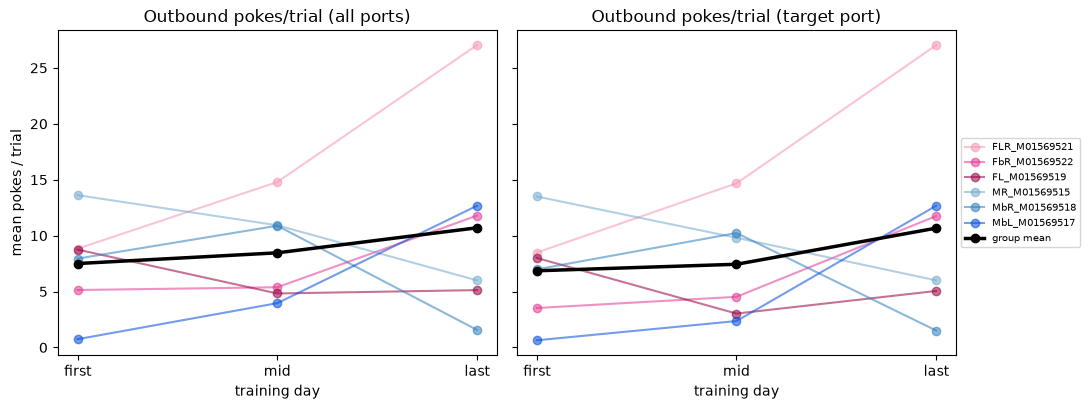

In [38]:
# Figure 1 | Outbound pokes/trial across first/mid/last (all ports + target port).
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
plot_pokes_per_day(poke_trials, axes[0], 'n_outbound_all', 'Outbound pokes/trial (all ports)')
plot_pokes_per_day(poke_trials, axes[1], 'n_outbound_target', 'Outbound pokes/trial (target port)')
axes[0].set_ylabel('mean pokes / trial')
axes[1].legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.tight_layout(); plt.show()

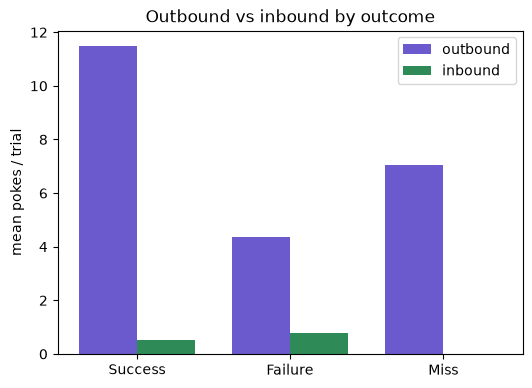

In [39]:
# Figure 2 | Outbound vs inbound pokes by outcome.
fig, ax = plt.subplots(figsize=(6, 4.2))
plot_outbound_vs_inbound(poke_trials, ax)
plt.show()

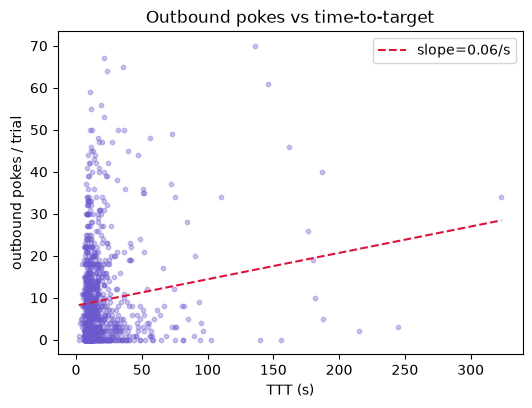

In [40]:
# Figure 3 | Outbound pokes vs TTT.
fig, ax = plt.subplots(figsize=(6, 4.2))
plot_pokes_vs_ttt(poke_trials, ax)
plt.show()

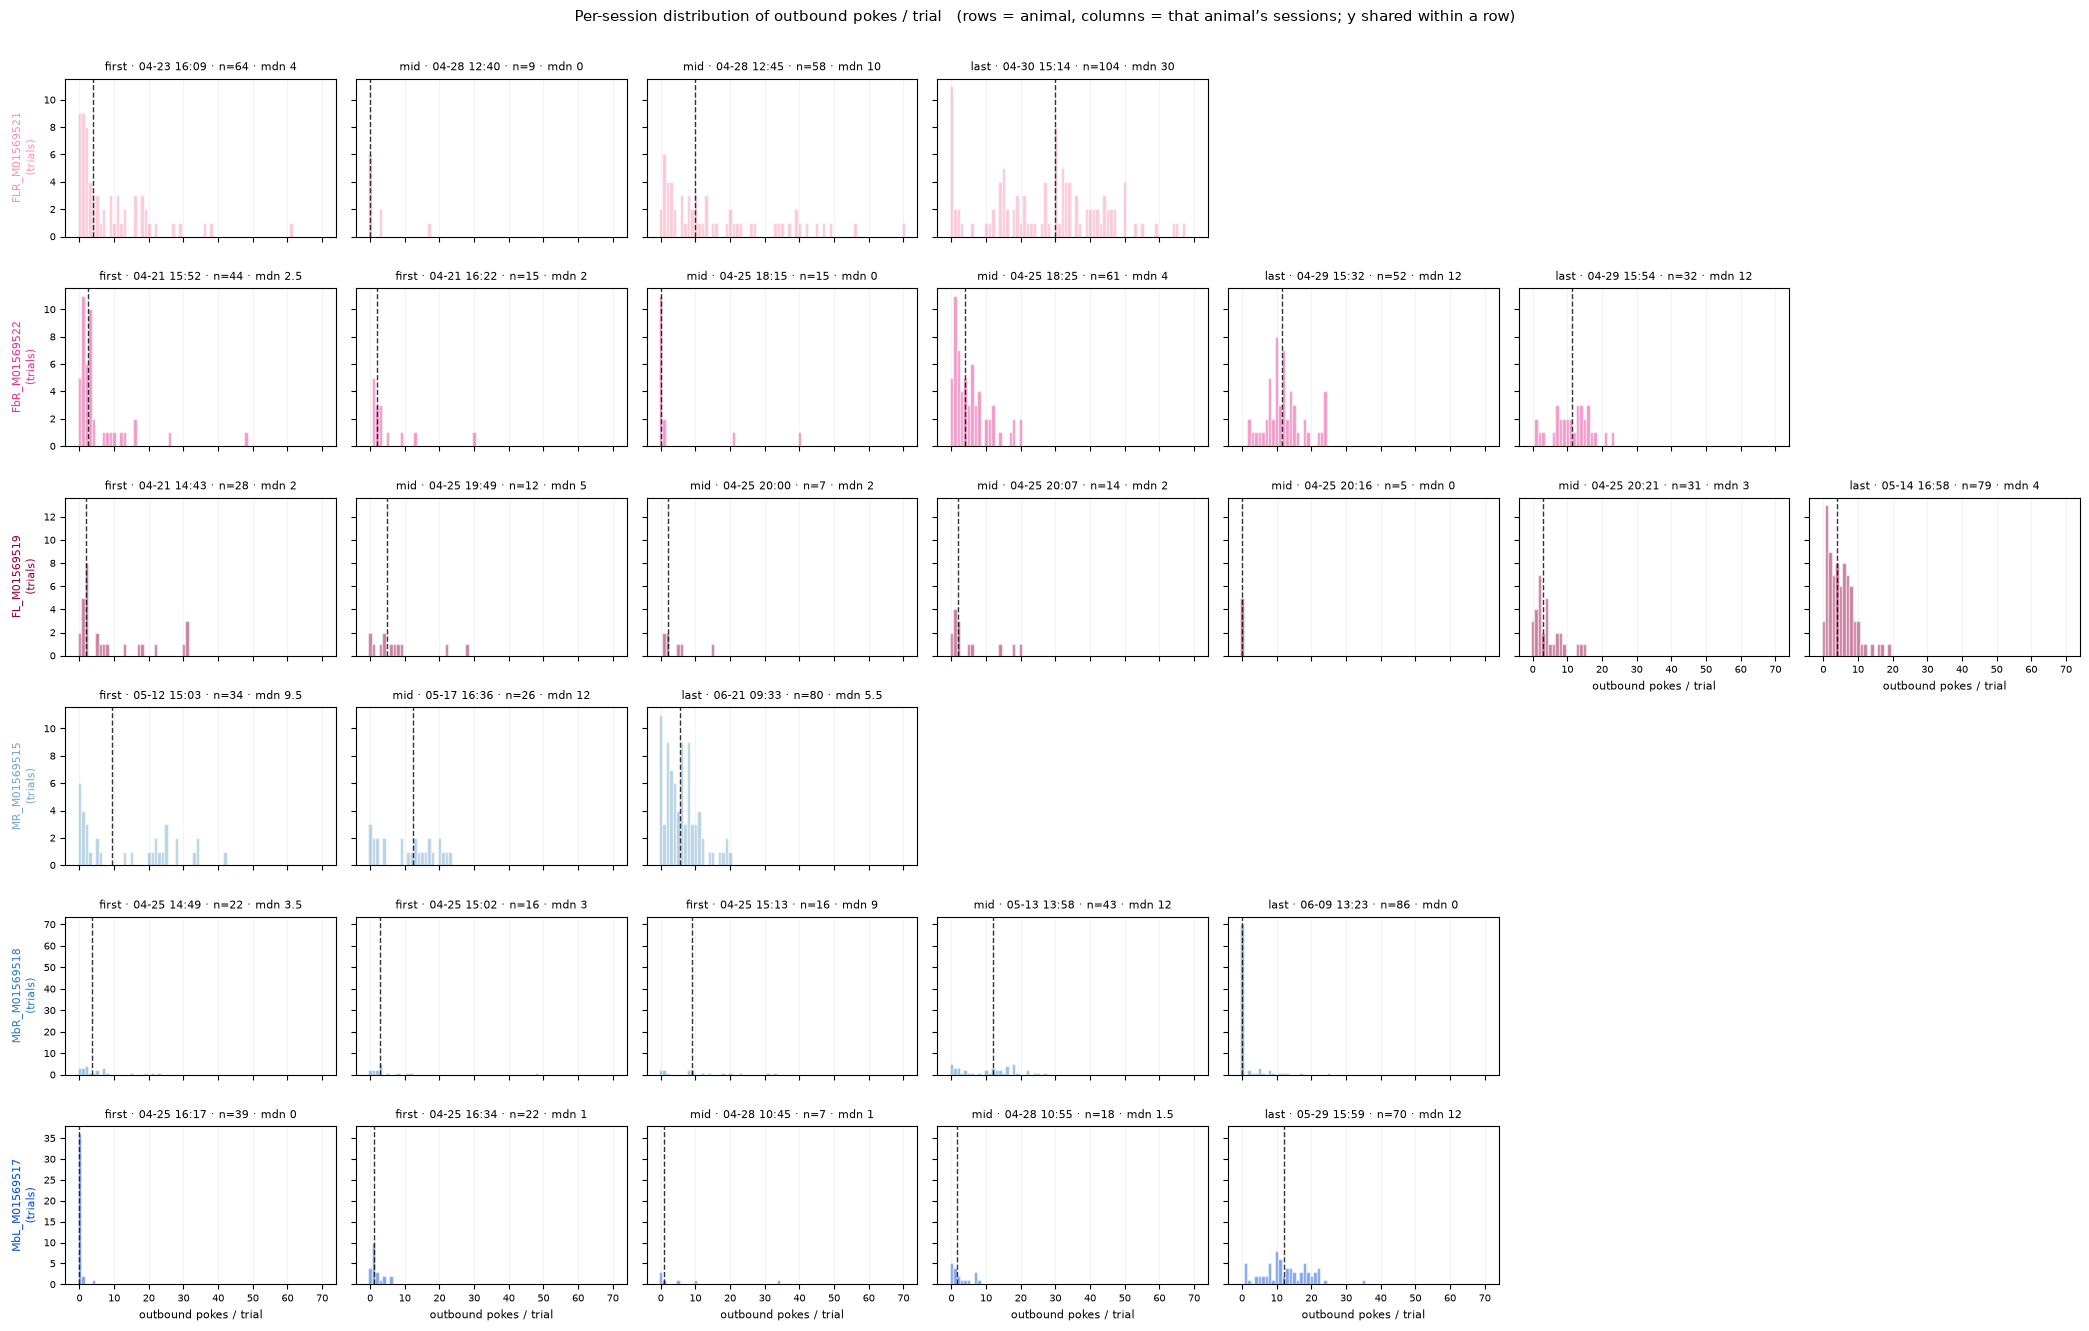

In [41]:
# Figure 3b | Per-session distribution of an outbound-poke metric (rows = animal, one panel/session).
# The distribution is over the TRIALS in each session. metric='rate' -> outbound pokes / TTT
# (pokes per second on the outbound leg, normalising for how long the outbound leg took);
# metric='count' -> raw n_outbound_all per trial.
# Axes are set up for readability: y is shared WITHIN each animal's row (so that animal's
# sessions sit on one comparable density/count scale) and labelled on the left; the x-label +
# tick labels are placed on the lowest POPULATED panel of every column (ragged-safe - otherwise
# the extra columns that only some animals have would show no x-axis); session ids are shortened
# to MM-DD HH:MM; and a dashed median line (+ median in the title) marks each session's typical value.
def _trial_metric(poke_trials, metric):
    """Return (rows-with-a `_value` column, x-axis label) for the chosen per-trial metric."""
    d = poke_trials.copy()
    if metric == 'rate':
        d = d[d['TTT'] > 0].copy()
        d['_value'] = d['n_outbound_all'] / d['TTT']
        return d.dropna(subset=['_value']), 'outbound pokes / s  (n_outbound_all / TTT)'
    if metric == 'count':
        d['_value'] = d['n_outbound_all'].astype(float)
        return d.dropna(subset=['_value']), 'outbound pokes / trial'
    raise ValueError("metric must be 'rate' or 'count'.")


def _short_session(s):
    """'2026-04-29T153239Z' -> '04-29 15:32' (drop year/seconds so titles stay legible)."""
    return f'{s[5:10]} {s[11:13]}:{s[13:15]}' if isinstance(s, str) and len(s) >= 15 else str(s)


def plot_poke_distributions(poke_trials, *, metric='rate', density=False,
                            mouse_colours=DEFAULT_MOUSE_COLOURS,
                            mouse_col='mouseID', session_col='session', day_col='training_day',
                            bins=18, kde=True, show_median=True, figsize_per_cell=(3.0, 2.2)):
    """Grid of per-session distributions of the per-trial metric: rows = animal, columns = that
    animal's sessions (ragged; blank where an animal has fewer sessions). x shared across the grid
    (same metric); y shared within each row. density=True -> comparable shapes; False -> trial counts."""
    d, xlabel = _trial_metric(poke_trials, metric)
    mice = [m for m in mouse_colours if m in set(d[mouse_col])] or sorted(d[mouse_col].unique())
    sessions_by_mouse = {m: sorted(d.loc[d[mouse_col] == m, session_col].unique()) for m in mice}
    ncols = max(len(v) for v in sessions_by_mouse.values())
    ylabel = 'density' if density else 'trials'

    # Shared bin edges (so panels are directly comparable). Count -> one bar per integer;
    # rate -> fixed linear bins up to the 99.5th pct (clip a rare long tail from dominating).
    if metric == 'count':
        bin_edges = np.arange(-0.5, np.nanmax(d['_value']) + 1.5, 1)
    else:
        bin_edges = np.linspace(0, np.nanpercentile(d['_value'], 99.5), bins + 1)

    fig, axes = plt.subplots(len(mice), ncols, squeeze=False, sharex=True, sharey='row',
                             figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * len(mice)))
    for r, m in enumerate(mice):
        colour = mouse_colours.get(m, '#666666')
        sess_list = sessions_by_mouse[m]
        for c in range(ncols):
            ax = axes[r][c]
            if c >= len(sess_list):
                ax.axis('off'); continue
            s = sess_list[c]
            rows = d[(d[mouse_col] == m) & (d[session_col] == s)]
            vals = rows['_value'].to_numpy()
            title = f'{TRAINING_PHASE_LABELS.get(rows[day_col].iloc[0] if len(rows) else None, "?")}' \
                    f' · {_short_session(s)} · n={len(vals)}'
            if len(vals):
                ax.hist(vals, bins=bin_edges, density=density, color=colour, alpha=0.5,
                        edgecolor='white')
                if kde and metric == 'rate' and density and len(vals) > 2 and vals.max() - vals.min() > 0:
                    try:
                        from scipy.stats import gaussian_kde
                        xs = np.linspace(bin_edges[0], bin_edges[-1], 200)
                        ax.plot(xs, gaussian_kde(vals)(xs), color=colour, lw=1.6)
                    except Exception:
                        pass
                if show_median:
                    med = float(np.median(vals))
                    ax.axvline(med, color='k', ls='--', lw=1.0, alpha=0.8)
                    title += f' · mdn {med:.2g}'
            ax.set_title(title, fontsize=8)
            ax.grid(axis='x', alpha=0.15)
            ax.tick_params(labelsize=7)
            if c == 0:
                ax.set_ylabel(f'{m}\n({ylabel})', fontsize=8, color=colour)

    # X-label + tick labels on the lowest POPULATED panel of each column (sharex/ragged-safe).
    for c in range(ncols):
        rr = max((r for r, m in enumerate(mice) if c < len(sessions_by_mouse[m])), default=None)
        if rr is not None:
            axes[rr][c].tick_params(labelbottom=True)
            axes[rr][c].set_xlabel(xlabel, fontsize=8)

    title_metric = 'outbound poke rate (pokes/s)' if metric == 'rate' else 'outbound pokes / trial'
    fig.suptitle(f'Per-session distribution of {title_metric}   '
                 f'(rows = animal, columns = that animal’s sessions; y shared within a row)',
                 y=1.005, fontsize=11)
    fig.tight_layout()
    return fig, axes


# Default view = the rate (pokes/TTT); flip to metric='count' for the raw per-trial poke counts,
# or density=False to read the y-axis as a trial count instead of a density.
fig, axes = plot_poke_distributions(poke_trials, metric='count')
plt.show()

## Figures 4 & 5 - spatial (nose position at each outbound poke)

Both figures ask *where in the arena* the animal pokes on the outbound leg, so both need
the real DLC pose + `UndistortedVideoData` frame - **render on the data PC only** (the
external drive holding the videos is where `_first_frame_for_session` reads from).

They share one primitive, built in the setup cell below: take every **outbound** poke onset
(the `tagged` table from the extraction cell, `leg == 'outbound'`), `merge_asof` its onset time
onto `pose_wide` to grab the mouse's **nose** `(x, y)` at that instant (nearest DLC frame,
matched within session), and colour it **target vs non-target** port. DLC ran on the
undistorted video, so the pose is in undistorted pixel coords and the background must be the
`UndistortedVideoData` frame (1620x1260), not the raw `VideoData` frame.

- **Figure 4 - poke locations on the arena.** For one mouse, columns = training phase
  (first/mid/last); each panel scatters the nose position of every outbound poke over that
  phase's arena frame.
- **Figure 5 - trial-by-trial animation.** Adapts `figure_overlay_animation` (Requested_plots
  Fig 1d): pick one (mouse, day); each animation step adds the next trial's outbound poke
  locations, so you watch the poke pattern build up across a day. Embeds a JS player
  (`HTML(ani.to_jshtml())`) - no ffmpeg needed.

Frame reads reuse the fault-tolerant `_safe_first_frame` wrapper from Requested_plots (a flaky
external-drive read falls back to a blank background instead of aborting the figure).

In [42]:
# Figures 4 & 5 setup | attach the nose (x, y) to every outbound poke onset.
# Builds pose_wide (same pivot as Requested_plots) and merge_asofs each outbound onset time
# onto it to grab the nearest DLC frame's nose position; also brings the fault-tolerant frame
# reader over from Requested_plots (fig 1b) so a flaky external-drive read can't abort a figure.
import time as _time
from data_conduit.qc.path_plots import _first_frame_for_session


def _safe_first_frame(root, session_id, video_subdir, cache, *, retries=2, backoff=0.5):
    """Fault-tolerant _first_frame_for_session. External-drive video reads intermittently
    fail (usually OSError from an ffmpeg metadata timeout) even when the file is fine; retry
    a few times, then fall back to None (blank background) with a warning. Cached per session."""
    if session_id in cache:
        return cache[session_id]
    frame = None
    for attempt in range(retries + 1):
        try:
            frame = _first_frame_for_session(root, session_id, video_subdir, {})   # fresh dict -> force read
            break
        except Exception as exc:   # any read failure -> blank background, never abort the figure
            if attempt < retries:
                _time.sleep(backoff)
                continue
            detail = (str(exc).strip().splitlines() or [''])[0][:100]
            print(f"warning: frame read failed for session {session_id!r} after "
                  f"{retries + 1} tries ({exc.__class__.__name__}: {detail}); "
                  f"drawing that panel without a background.")
    cache[session_id] = frame
    return frame


# Wide pose table: one row per (session, Time) with <keypoint>_<space> columns (incl. nose_x/nose_y).
pose_wide = (
    result['dlc:position'].to_dataframe(name='value').reset_index()
    .pivot_table(index=['session', 'Time'], columns=['keypoints', 'space'], values='value')
)
pose_wide.columns = [f'{keypoint}_{space}' for keypoint, space in pose_wide.columns]
pose_wide = pose_wide.reset_index()


def attach_pose(onsets, pose_wide, *, keypoint='nose', session_col='session', time_col='Time'):
    """Attach the nearest DLC-frame <keypoint> (x, y) to each poke onset, matched within
    session (merge_asof, direction='nearest'). Onsets in sessions with no pose get NaN and
    are dropped by the plotters below."""
    x, y = f'{keypoint}_x', f'{keypoint}_y'
    o = onsets.sort_values(time_col).reset_index(drop=True)
    p = pose_wide[[session_col, time_col, x, y]].sort_values(time_col).reset_index(drop=True)
    return pd.merge_asof(o, p, on=time_col, by=session_col, direction='nearest')


# Outbound onsets only, with nose position + (mouseID, training_day) for per-mouse/day slicing.
sess_meta = trials_filtered[['session', 'mouseID', 'training_day']].drop_duplicates()
poke_nose = (attach_pose(tagged[tagged['leg'] == 'outbound'], pose_wide)
             .merge(sess_meta, on='session', how='left'))
poke_nose[['mouseID', 'training_day', 'trial_index', 'port_index', 'is_target',
           'nose_x', 'nose_y']].head()

,mouseID,training_day,trial_index,port_index,is_target,nose_x,nose_y
0,FLR_M01569521,3,6.0,0,True,1321.852905,299.137512
1,FLR_M01569521,3,6.0,0,True,1320.032837,297.805969
2,FLR_M01569521,3,6.0,0,True,1319.964722,297.849731
3,FLR_M01569521,3,6.0,0,True,1320.436035,298.419464
4,FLR_M01569521,3,6.0,0,True,1320.397705,297.717194


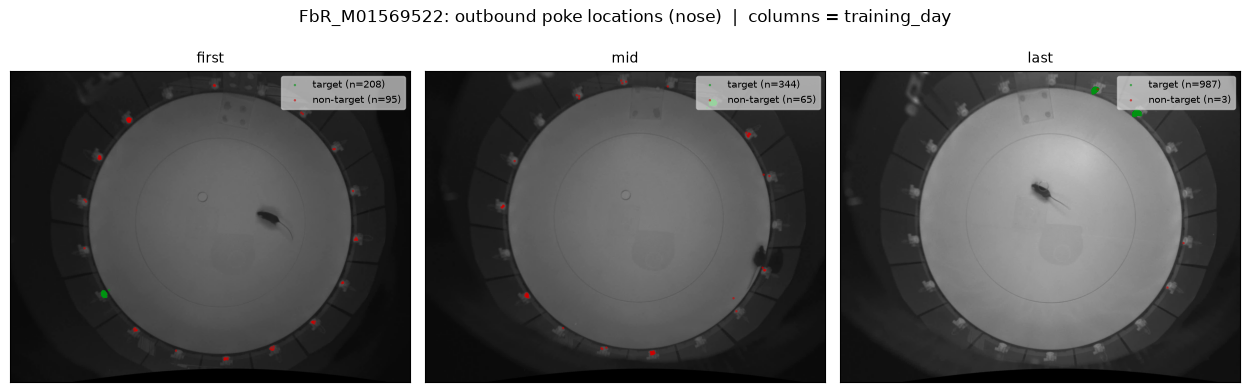

In [43]:
# Figure 4 | Outbound poke locations on the arena (nose position per outbound poke).
# One mouse; columns = training phase (first/mid/last). Each panel scatters the nose (x, y)
# at every outbound poke onset over that phase's arena frame, coloured target vs non-target
# port. A shared pixel extent keeps the whole arena visible even where a panel has few pokes.
# Repeated pokes at one port land on near-identical pixels, so points are given a small random
# jitter (+/- `jitter` px, seeded for reproducibility) to reveal how many overlap.
TARGET_COLOURS = {'target': "#009411", 'non-target': "#d10000ff"}


def _add_jitter(df, x, y, jitter, seed):
    """Return a copy of df with jittered `_jx`/`_jy` columns (+/- jitter px, seeded)."""
    df = df.copy()
    rng = np.random.default_rng(seed)
    df['_jx'] = df[x] + rng.uniform(-jitter, jitter, len(df))
    df['_jy'] = df[y] + rng.uniform(-jitter, jitter, len(df))
    return df


def figure_poke_locations(
        poke_nose, root, mouse, *,
        group_by='training_day', mouse_col='mouseID', session_col='session',
        x='nose_x', y='nose_y', video_subdir='UndistortedVideoData',
        colours=TARGET_COLOURS, marker_size=3, alpha=0.6, jitter=6.0, seed=0,
        figsize_per_cell=(4.2, 3.8)):
    """Scatter grid of outbound poke nose-locations for ONE mouse (columns = group_by).
    jitter: +/- pixels of random scatter added so overlapping pokes are visible (0 = off)."""
    sub = poke_nose[poke_nose[mouse_col] == mouse].dropna(subset=[x, y])
    if sub.empty:
        raise ValueError(f'no located outbound pokes for mouse {mouse!r} '
                         '(no pose in these sessions?).')
    sub = _add_jitter(sub, x, y, jitter, seed)

    # One frame per session, up front and fault-tolerantly (shared pixel extent).
    frame_cache = {}
    for s in pd.unique(sub[session_col]):
        _safe_first_frame(root, s, video_subdir, frame_cache)
    ref = next((f for f in frame_cache.values() if f is not None), None)
    extent = ref.shape[:2] if ref is not None else None   # (H, W)

    fig, axes = plt.subplots(1, len(groupings := sorted(pd.unique(sub[group_by]))), squeeze=False,
                             figsize=(figsize_per_cell[0] * len(groupings), figsize_per_cell[1]))
    for ci, g in enumerate(groupings):
        ax = axes[0][ci]
        gdf = sub[sub[group_by] == g]
        bg = frame_cache.get(gdf[session_col].iloc[0])   # background drawn once per panel
        if bg is not None:
            ax.imshow(bg, origin='upper')
        for is_tgt, lab in ((True, 'target'), (False, 'non-target')):
            d = gdf[gdf['is_target'] == is_tgt]
            ax.scatter(d['_jx'], d['_jy'], s=marker_size, alpha=alpha, color=colours[lab],
                       edgecolors='none', label=f'{lab} (n={len(d)})')
        if extent is not None:
            ax.set_xlim(0, extent[1]); ax.set_ylim(extent[0], 0)
        else:
            ax.invert_yaxis()
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(TRAINING_PHASE_LABELS.get(g, g), fontsize=10)
        ax.legend(fontsize=7, loc='upper right', framealpha=0.6)
    fig.suptitle(f'{mouse}: outbound poke locations (nose)  |  columns = {group_by}', y=1.03)
    fig.tight_layout()
    return fig, axes


# One mouse at a time keeps the arena readable; pass any mouseID present in poke_nose.
fig, axes = figure_poke_locations(poke_nose, ROOT, 'FbR_M01569522')
plt.show()

In [44]:
# Figure 5 | Trial-by-trial animation of outbound poke locations for ONE (mouse, day).
# Adapts Requested_plots fig 1d (figure_overlay_animation). Two panels animate in sync:
#   left  - arena: cumulative outbound poke nose-locations, coloured target vs non-target;
#   right - a bar per trial (in poke-time order) giving that trial's outbound poke count
#           (target stacked under non-target), so you can read how many pokes per trial as the
#           spatial pattern builds. The current trial's bar is outlined + its count annotated.
# Bar heights = the dots added that step (both come from the same `sub`), so the two panels
# agree. Trials with zero located outbound pokes aren't in `sub`, so they don't get a frame/bar.
# Dots get a small seeded jitter (computed ONCE, so a poke keeps its position across frames) to
# reveal overlapping pokes at the same port. Reuses _add_jitter from the Figure 4 cell.
from matplotlib import animation
from matplotlib.lines import Line2D
from IPython.display import HTML


def figure_poke_animation(
        poke_nose, root, mouse, day, *,
        group_by='training_day', mouse_col='mouseID', session_col='session',
        trial_col='trial_index', time_col='Time', x='nose_x', y='nose_y',
        video_subdir='UndistortedVideoData', colours=TARGET_COLOURS,
        marker_size=3, alpha=0.8, jitter=6.0, seed=0, figsize=(10.0, 4.8),
        interval=350, repeat=False):
    """Cumulative outbound-poke animation for ONE (mouse, day): arena scatter + per-trial
    poke-count bars. jitter: +/- px of seeded scatter so overlapping pokes are visible (0 = off)."""
    sub = poke_nose[(poke_nose[mouse_col] == mouse)
                    & (poke_nose[group_by] == day)].dropna(subset=[x, y]).copy()
    if sub.empty:
        raise ValueError(f'no located outbound pokes for mouse {mouse!r} {group_by}={day!r}.')

    # Order trials by first outbound poke time (trial_index can restart across a day's sessions).
    order = (sub.groupby([session_col, trial_col])[time_col].min()
             .sort_values().index.tolist())
    rank = {key: i for i, key in enumerate(order)}
    sub['trial_ord'] = [rank[(s, t)] for s, t in zip(sub[session_col], sub[trial_col])]
    n_trials = len(order)
    sub = _add_jitter(sub, x, y, jitter, seed)   # fixed per-poke jitter (columns _jx/_jy)

    # Per-trial poke counts (target / non-target), indexed 0..n_trials-1 to match trial_ord.
    counts = (sub.groupby('trial_ord')
              .agg(total=('is_target', 'size'), target=('is_target', 'sum'))
              .reindex(range(n_trials), fill_value=0))
    counts['nontarget'] = counts['total'] - counts['target']
    tgt, ntgt, tot = (counts['target'].to_numpy(), counts['nontarget'].to_numpy(),
                      counts['total'].to_numpy())
    ymax = max(int(tot.max()), 1)

    # Static background + shared pixel extent (one day -> one representative frame).
    frame_cache = {}
    for s in pd.unique(sub[session_col]):
        _safe_first_frame(root, s, video_subdir, frame_cache)
    bg = frame_cache.get(sub[session_col].iloc[0])
    ref = next((f for f in frame_cache.values() if f is not None), None)
    extent = ref.shape[:2] if ref is not None else None   # (H, W)

    fig, (ax, ax2) = plt.subplots(1, 2, figsize=figsize,
                                  gridspec_kw={'width_ratios': [1.35, 1.0]})
    if bg is not None:
        ax.imshow(bg, origin='upper')
    if extent is not None:
        ax.set_xlim(0, extent[1]); ax.set_ylim(extent[0], 0)
    else:
        ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(handles=[Line2D([0], [0], marker='o', ls='', mfc=colours[lab], mec='none',
                              label=lab) for lab in ('target', 'non-target')],
              fontsize=8, loc='upper right', framealpha=0.6)

    def draw(k):
        # Left: cumulative arena scatter (redraw fresh each frame).
        for coll in list(ax.collections):
            coll.remove()
        cur = sub[sub['trial_ord'] <= k]
        for is_tgt, lab in ((True, 'target'), (False, 'non-target')):
            d = cur[cur['is_target'] == is_tgt]
            ax.scatter(d['_jx'], d['_jy'], s=marker_size, alpha=alpha, color=colours[lab],
                       edgecolors='white', linewidths=0.4)
        ax.set_title(f'{mouse}  {group_by}={day}  |  trials 1..{k + 1} of {n_trials}', fontsize=10)

        # Right: per-trial poke counts up to the current trial (target stacked under non-target).
        ax2.cla()
        xs = np.arange(1, k + 2)                       # trial numbers 1..k+1 (poke-time order)
        ax2.bar(xs, tgt[:k + 1], width=0.85, color=colours['target'], alpha=0.75, label='target')
        ax2.bar(xs, ntgt[:k + 1], bottom=tgt[:k + 1], width=0.85, color=colours['non-target'],
                alpha=0.75, label='non-target')
        ax2.bar([k + 1], [tot[k]], width=0.85, facecolor='none', edgecolor='black',
                linewidth=1.6, zorder=5)             # outline the current trial
        ax2.annotate(str(int(tot[k])), (k + 1, tot[k]), textcoords='offset points',
                     xytext=(0, 3), ha='center', fontsize=8, fontweight='bold')
        ax2.set_xlim(0.5, n_trials + 0.5); ax2.set_ylim(0, ymax * 1.18)
        ax2.set_xlabel('trial (poke-time order within day)'); ax2.set_ylabel('outbound pokes')
        ax2.set_title(f'pokes / trial  (current #{k + 1}: {int(tot[k])})', fontsize=10)
        return []

    fig.tight_layout()
    ani = animation.FuncAnimation(fig, draw, frames=n_trials,
                                  init_func=lambda: [], interval=interval, blit=False, repeat=repeat)
    plt.close(fig)   # show via the JS player below, not as a static figure
    return ani


# Pick ONE (mouse, day); embeds a JS player (play/pause/scrub) in the cell output.
ani = figure_poke_animation(poke_nose, ROOT, 'FbR_M01569522', day=1)
HTML(ani.to_jshtml())